# Packages

In [434]:
import one_hot_encoder
from keras import Input
from utilsforecast.plotting import plot_series
%pip install sklearn
%pip install pandas
%pip install numpy
%pip install xgboost
%pip install matplotlib
%pip install seaborn
%pip install xgboost
%pip install cleanlab
%pip install ipywidgets
%pip install imbalanced-learn
%pip install statsmodels
%pip install shap
%pip install prophet
%pip install plotly
%pip install tensorflow
%pip install scipy
%pip install statsforecast
%pip install utilsforecast


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
    

# Imports

In [435]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cleanlab.filter import find_label_issues
from imblearn.under_sampling import RandomUnderSampler
from matplotlib import cm
from sklearn.cluster import KMeans
from sklearn.decomposition import (
    PCA,
    TruncatedSVD
)
from sklearn.ensemble import IsolationForest, RandomForestClassifier, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    accuracy_score,
    mean_squared_error,
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    StratifiedKFold,
    TimeSeriesSplit,
    cross_val_predict,
    train_test_split
)
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
    Binarizer,
    FunctionTransformer,
    OneHotEncoder
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stl.mstl import MSTL
import shap
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, LSTM, Conv1D,
                                     GlobalMaxPooling1D, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from statsforecast.models import (
    AutoARIMA,
    Naive,
    HistoricAverage,
    WindowAverage,
    SeasonalNaive,
)
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

# Functions

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#trigonometric-features

In [436]:
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))


def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

In [437]:
def sklearnEvaluate(model, X, y, cv, model_prop=None, model_step=None):
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error"],
        return_estimator=model_prop is not None,
    )
    if model_prop is not None:
        if model_step is not None:
            values = [
                getattr(m[model_step], model_prop) for m in cv_results["estimator"]
            ]
        else:
            values = [getattr(m, model_prop) for m in cv_results["estimator"]]
        print(f"Mean model.{model_prop} = {np.mean(values)}")
    mae = -cv_results["test_neg_mean_absolute_error"]
    rmse = -cv_results["test_neg_root_mean_squared_error"]
    print(
        f"Mean Absolute Error:     {mae.mean():.3f} +/- {mae.std():.3f}\n"
        f"Root Mean Squared Error: {rmse.mean():.3f} +/- {rmse.std():.3f}"
    )

In [438]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tf_style_predictions(X_3D, y_3D, model, feature_index=0, num_plots=3):
    """
    Creates a stacked plot exactly like the TensorFlow Time Series tutorial.

    Parameters:
    X_3D: Your 3D testing features (Samples, Time_Steps, Features)
    y_3D: Your testing labels
    model: Your trained LSTM/CNN model
    feature_index: Which feature to draw the blue line for (e.g., 0 for PM2.5)
    num_plots: How many subplots to stack (the image has 3)
    """
    # 1. Get the model's predictions for the test set
    # Using > 0.5 to convert the probability back into a 1 or 0
    predictions = (model.predict(X_3D) > 0.5).astype(int)

    # 2. Set up the figure with multiple subplots stacked vertically
    fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 8))

    # 3. Loop through to draw a few random examples from your test set
    # (We multiply by 100 just to space out the examples we pick)
    for i, ax in enumerate(axes):
        sample_idx = i * 100

        # Extract the sequence of inputs for the blue line
        inputs = X_3D[sample_idx, :, feature_index]
        input_time_steps = list(range(len(inputs)))

        # The label/prediction happens at the time step immediately after the inputs
        target_time = len(inputs)
        label = y_3D[sample_idx]
        prediction = predictions[sample_idx][0]

        # --- DRAWING THE TF STYLE PLOT ---

        # Plot 1: The Inputs (Blue line with dots)
        ax.plot(input_time_steps, inputs, label='Inputs', marker='.', zorder=-10)

        # Plot 2: The True Label (Green Circle with black edge)
        ax.scatter(target_time, label, edgecolors='k', label='Labels',
                   c='#2ca02c', s=64, zorder=2)

        # Plot 3: The Prediction (Orange X with black edge)
        ax.scatter(target_time, prediction, marker='X', edgecolors='k',
                   label='Predictions', c='#ff7f0e', s=64, zorder=3)

        # Formatting to match the tutorial
        ax.set_ylabel('Scaled Feature')
        if i == 0:
            ax.legend() # Only put the legend on the top plot

    # Add the x-axis label only to the very bottom plot
    axes[-1].set_xlabel('Time [h]')

    plt.tight_layout()
    plt.show()

# How to use it:
# (Assuming your scaled PM2.5 is at index 0 of your features)
# plot_tf_style_predictions(X_test_3D, y_test_3D, lstm_model, feature_index=0, num_plots=3)

In [537]:
def max_missing_sequence(ser):
    # 1. Mask for null values
    is_null = ser.isnull()

    # 2. Group consecutive booleans
    # (True -> False or False -> True increments the group)
    groups = (is_null != is_null.shift()).astype(int).cumsum()

    # 3. Filter to only look at the 'True' (null) groups and count them
    null_counts = is_null[is_null].groupby(groups).size()

    # 4. Return the max, or 0 if no nulls exist
    return null_counts.max() if not null_counts.empty else 0


# Data Preprocessing

In [538]:
# Find all files that start with "PRSA_Data" and end with ".csv"
file_paths = glob.glob("./beijing+multi+site+air+quality+data/PRSA_Data_20130301-20170228/PRSA_Data_*.csv")

# Read all into a list
dataframes = [pd.read_csv(file) for file in file_paths]

# Combine them all together into one giant dataset
df_all = pd.concat(dataframes, ignore_index=True)

df_all['wd'] = df_all['wd'].astype('category')
df_all['station'] = df_all['station'].astype('category')

df_all['datetime'] = pd.to_datetime(df_all[['year', 'month', 'day', 'hour']])
df_all['DayOfWeek'] = df_all['datetime'].dt.dayofweek

# Create a binary feature: 1 if it is Saturday (5) or Sunday (6), 0 if weekday
df_all['Is_Weekend'] = (df_all['DayOfWeek'] >= 5).astype(int)

# Create a binary feature for "Rush Hour" (e.g., 7 AM to 9 AM, and 5 PM to 7 PM)
df_all['Is_Rush_Hour'] = df_all['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

categorical_columns = df_all.columns[df_all.dtypes == "category"]

one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cyclicTransformer = ColumnTransformer(
    transformers=[
        # ("categorical", one_hot_encoder, categorical_columns),
        ("month_sin", sin_transformer(12), ["month"]),
        ("month_cos", cos_transformer(12), ["month"]),
        ("weekday_sin", sin_transformer(7), ["DayOfWeek"]),
        ("weekday_cos", cos_transformer(7), ["DayOfWeek"]),
        ("hour_sin", sin_transformer(24), ["hour"]),
        ("hour_cos", cos_transformer(24), ["hour"]),
    ],
    remainder=MinMaxScaler(),
)

df_all['month_sin'] = np.sin(df_all['month'] / 12 * 2 * np.pi)
df_all['month_cos'] = np.cos(df_all['month'] / 12 * 2 * np.pi)
df_all['weekday_sin'] = np.sin(df_all['DayOfWeek'] / 7 * 2 * np.pi)
df_all['weekday_cos'] = np.cos(df_all['DayOfWeek'] / 7 * 2 * np.pi)
df_all['hour_sin'] = np.sin(df_all['hour'] / 24 * 2 * np.pi)
df_all['hour_cos'] = np.cos(df_all['hour'] / 24 * 2 * np.pi)

# Sort by station FIRST, then by time.
df_all = df_all.sort_values(by=['station', 'datetime']).reset_index(drop=True)

In [539]:
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 28 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   No            420768 non-null  int64         
 1   year          420768 non-null  int64         
 2   month         420768 non-null  int64         
 3   day           420768 non-null  int64         
 4   hour          420768 non-null  int64         
 5   PM2.5         412029 non-null  float64       
 6   PM10          414319 non-null  float64       
 7   SO2           411747 non-null  float64       
 8   NO2           408652 non-null  float64       
 9   CO            400067 non-null  float64       
 10  O3            407491 non-null  float64       
 11  TEMP          420370 non-null  float64       
 12  PRES          420375 non-null  float64       
 13  DEWP          420365 non-null  float64       
 14  RAIN          420378 non-null  float64       
 15  wd            418946 non-nul

## Do we have missing data?

In [540]:
df_all.isnull().sum().sort_values(ascending=False)

CO              20701
O3              13277
NO2             12116
SO2              9021
PM2.5            8739
PM10             6449
wd               1822
DEWP              403
TEMP              398
PRES              393
RAIN              390
WSPM              318
Is_Weekend          0
weekday_sin         0
weekday_cos         0
month_cos           0
hour_sin            0
month_sin           0
Is_Rush_Hour        0
No                  0
DayOfWeek           0
datetime            0
station             0
year                0
hour                0
day                 0
month               0
hour_cos            0
dtype: int64

In [543]:
longest_gaps = df_all.apply(max_missing_sequence)
longest_gaps

No                 0
year               0
month              0
day                0
hour               0
PM2.5            343
PM10             343
SO2              457
NO2              900
CO              1517
O3               497
TEMP               7
PRES               7
DEWP               7
RAIN               6
wd                13
WSPM               5
station            0
datetime           0
DayOfWeek          0
Is_Weekend         0
Is_Rush_Hour       0
month_sin          0
month_cos          0
weekday_sin        0
weekday_cos        0
hour_sin           0
hour_cos           0
dtype: int64

In [545]:
df_with_nans = df_all[df_all.isnull().any(axis=1)]
df_with_nans

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,datetime,DayOfWeek,Is_Weekend,Is_Rush_Hour,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos
74,75,2013,3,4,2,34.0,62.0,NaN,14.0000,300.0,...,2013-03-04 02:00:00,0,0,0,1.000000,6.123234e-17,0.000000,1.000000,5.000000e-01,0.866025
75,76,2013,3,4,3,12.0,34.0,6.0000,12.0000,NaN,...,2013-03-04 03:00:00,0,0,0,1.000000,6.123234e-17,0.000000,1.000000,7.071068e-01,0.707107
76,77,2013,3,4,4,7.0,18.0,14.0000,NaN,400.0,...,2013-03-04 04:00:00,0,0,0,1.000000,6.123234e-17,0.000000,1.000000,8.660254e-01,0.500000
124,125,2013,3,6,4,192.0,203.0,83.6808,140.4252,NaN,...,2013-03-06 04:00:00,2,0,0,1.000000,6.123234e-17,0.974928,-0.222521,8.660254e-01,0.500000
170,171,2013,3,8,2,339.0,400.0,NaN,162.0000,3899.0,...,2013-03-08 02:00:00,4,0,0,1.000000,6.123234e-17,-0.433884,-0.900969,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420732,35029,2017,2,27,12,NaN,NaN,NaN,NaN,NaN,...,2017-02-27 12:00:00,0,0,0,0.866025,5.000000e-01,0.000000,1.000000,1.224647e-16,-1.000000
420733,35030,2017,2,27,13,NaN,NaN,NaN,NaN,NaN,...,2017-02-27 13:00:00,0,0,0,0.866025,5.000000e-01,0.000000,1.000000,-2.588190e-01,-0.965926
420758,35055,2017,2,28,14,3.0,6.0,NaN,5.0000,NaN,...,2017-02-28 14:00:00,1,0,0,0.866025,5.000000e-01,0.781831,0.623490,-5.000000e-01,-0.866025
420759,35056,2017,2,28,15,11.0,21.0,2.0000,5.0000,200.0,...,2017-02-28 15:00:00,1,0,0,0.866025,5.000000e-01,0.781831,0.623490,-7.071068e-01,-0.707107


## Handling Missing Data - Forward-fill missing values

Forward fill and backward fill are methods used to handle missing values in time series data by propagating the last or next valid observation, respectively. These methods help maintain the continuity of observations in your dataset.

https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html#filling-missing-data
https://hatefdastour.github.io/notes/Introduction_to_Python_Programming/chapter_05/PyIntro_C05S07.html

In [536]:
df_all = (
    df_all
    .set_index('station')
    .groupby('station')
    .ffill()
    .bfill()
    .reset_index()
)

In [443]:
df_all.isnull().sum().sort_values(ascending=False)

station         0
No              0
hour_sin        0
weekday_cos     0
weekday_sin     0
month_cos       0
month_sin       0
Is_Rush_Hour    0
Is_Weekend      0
DayOfWeek       0
datetime        0
WSPM            0
wd              0
RAIN            0
DEWP            0
PRES            0
TEMP            0
O3              0
CO              0
NO2             0
SO2             0
PM10            0
PM2.5           0
hour            0
day             0
month           0
year            0
hour_cos        0
dtype: int64

In [444]:
df_all.columns.to_list()

['station',
 'No',
 'year',
 'month',
 'day',
 'hour',
 'PM2.5',
 'PM10',
 'SO2',
 'NO2',
 'CO',
 'O3',
 'TEMP',
 'PRES',
 'DEWP',
 'RAIN',
 'wd',
 'WSPM',
 'datetime',
 'DayOfWeek',
 'Is_Weekend',
 'Is_Rush_Hour',
 'month_sin',
 'month_cos',
 'weekday_sin',
 'weekday_cos',
 'hour_sin',
 'hour_cos']

In [445]:
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 28 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   station       420768 non-null  category      
 1   No            420768 non-null  int64         
 2   year          420768 non-null  int64         
 3   month         420768 non-null  int64         
 4   day           420768 non-null  int64         
 5   hour          420768 non-null  int64         
 6   PM2.5         420768 non-null  float64       
 7   PM10          420768 non-null  float64       
 8   SO2           420768 non-null  float64       
 9   NO2           420768 non-null  float64       
 10  CO            420768 non-null  float64       
 11  O3            420768 non-null  float64       
 12  TEMP          420768 non-null  float64       
 13  PRES          420768 non-null  float64       
 14  DEWP          420768 non-null  float64       
 15  RAIN          420768 non-nul

In [446]:
df_all.describe().transpose()


,count,mean,min,25%,50%,75%,max,std
No,420768.0,17532.5,1.0,8766.75,17532.5,26298.25,35064.0,10122.116943
year,420768.0,2014.66256,2013.0,2014.0,2015.0,2016.0,2017.0,1.177198
month,420768.0,6.52293,1.0,4.0,7.0,10.0,12.0,3.448707
day,420768.0,15.729637,1.0,8.0,16.0,23.0,31.0,8.800102
hour,420768.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922195
PM2.5,420768.0,80.150342,2.0,20.0,55.0,112.0,999.0,81.296332
PM10,420768.0,105.062381,2.0,36.0,82.0,146.0,999.0,92.671498
SO2,420768.0,15.933593,0.2856,3.0,7.0,20.0,500.0,22.281831
NO2,420768.0,50.532428,1.0265,23.0,43.0,71.0,290.0,35.312577
CO,420768.0,1240.240736,100.0,500.0,900.0,1500.0,10000.0,1170.862949


# Evolution of a features over time

In [447]:
features = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3','TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df_single_station = df_all # [df_all['station'] == 'Aotizhongxin'].copy()
df_daily = df_single_station.set_index("datetime")
df_daily = df_daily[features].resample('D').mean().dropna()

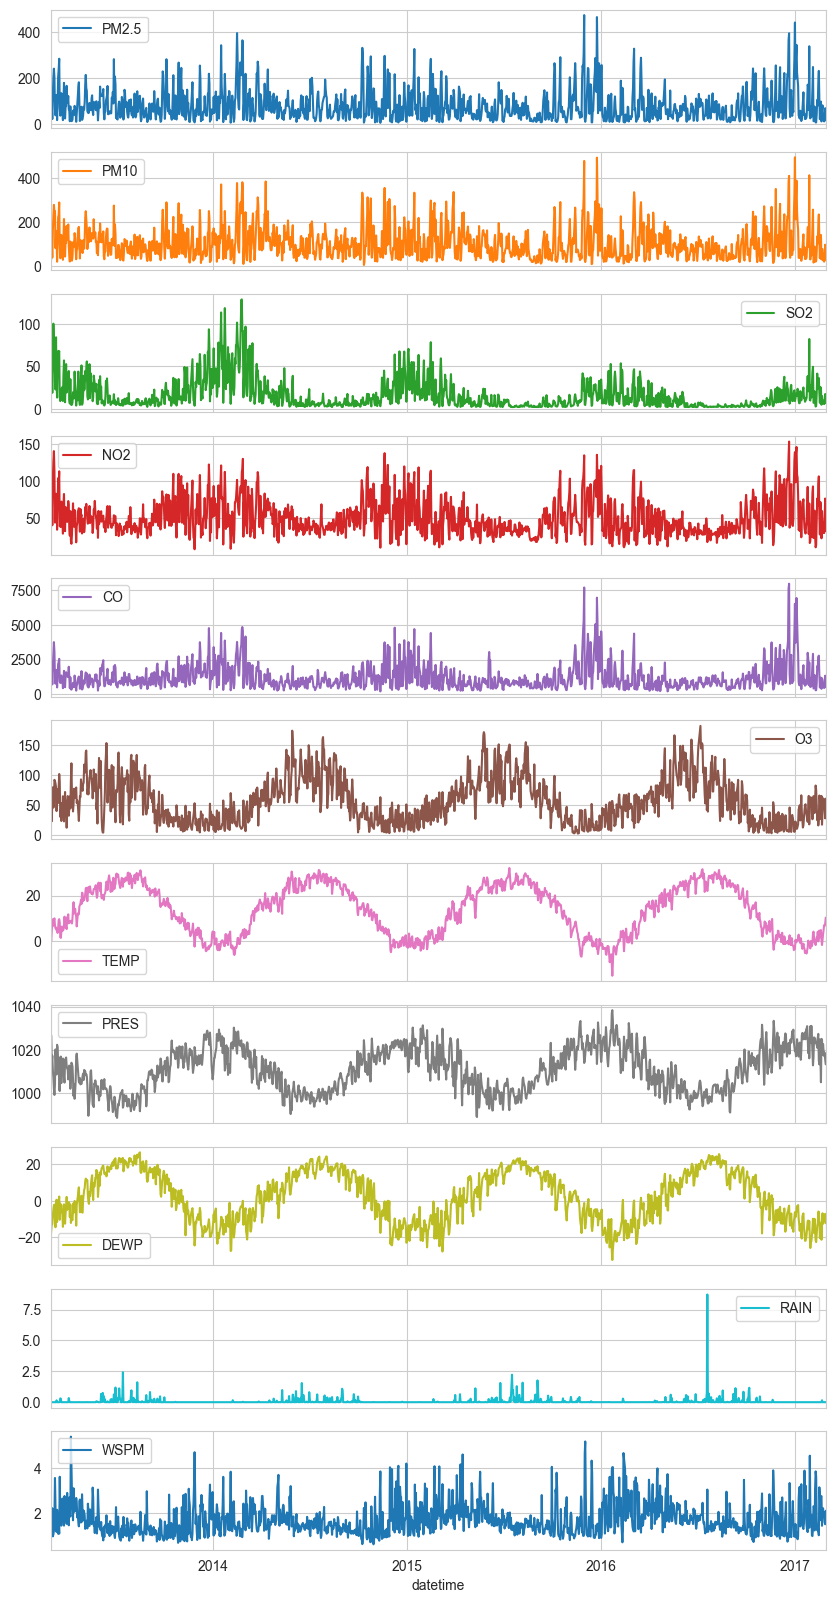

In [448]:
_ = df_daily.plot(subplots=True, figsize=(10, 20))

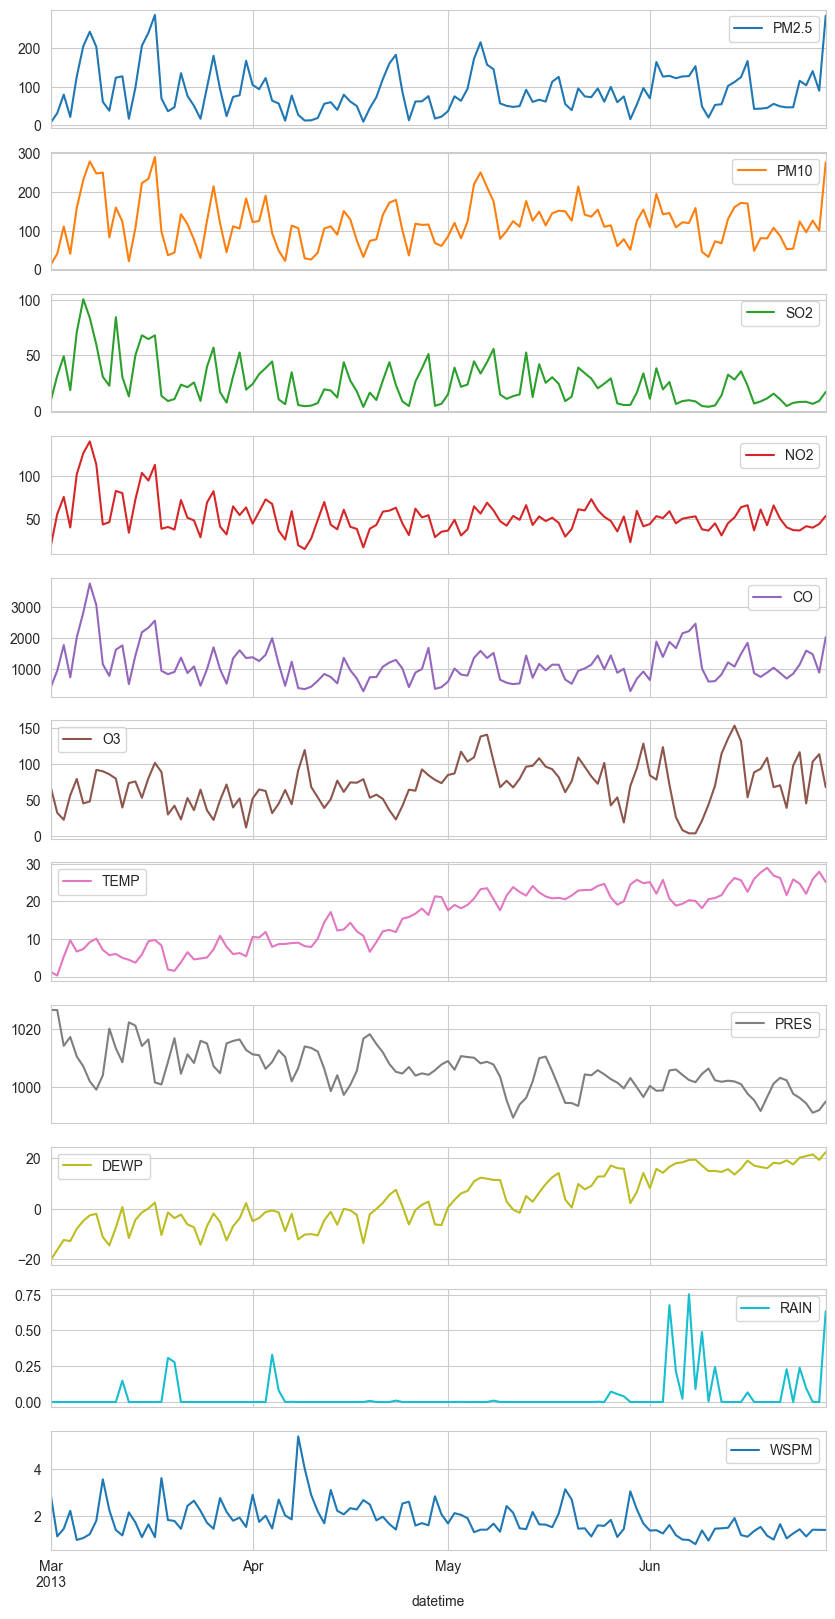

In [449]:
_ = df_daily[:120].plot(subplots=True, figsize=(10, 20))

# Density Distribution

array([<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>], dtype=object)

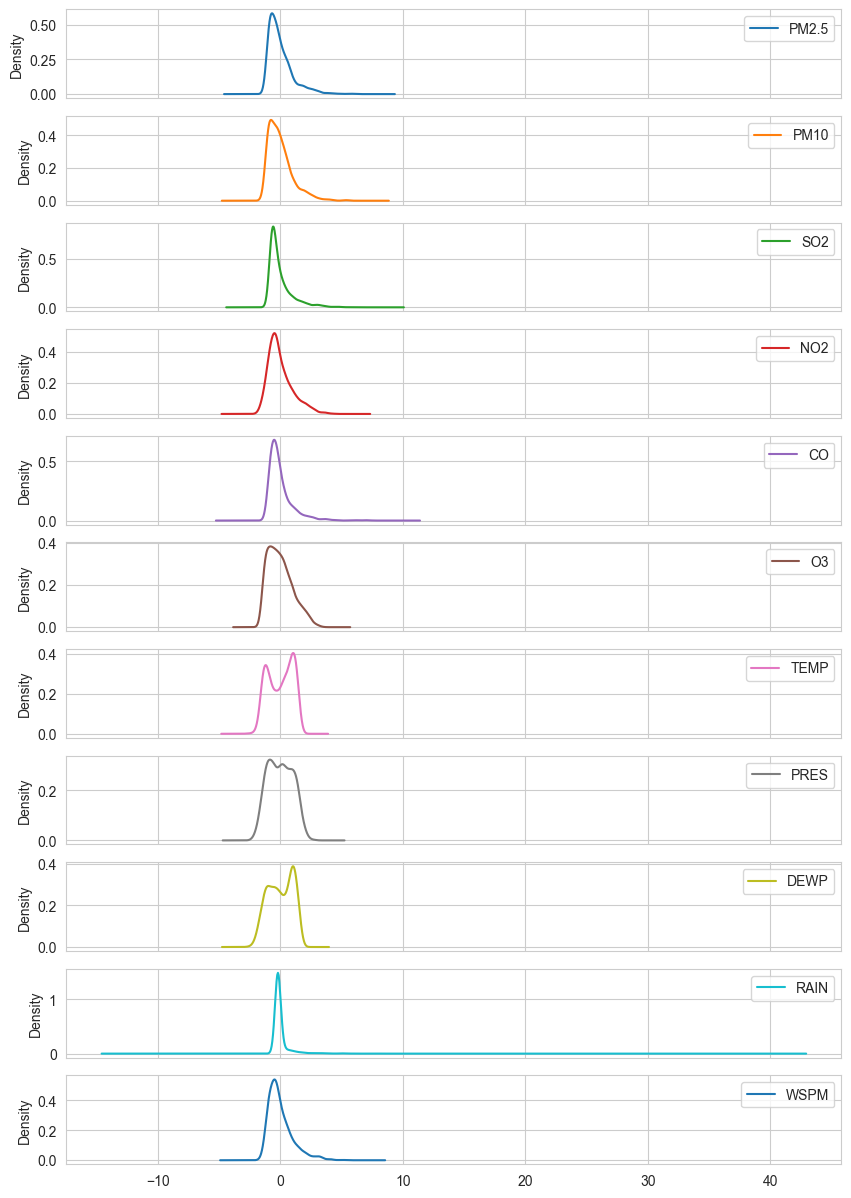

In [450]:
scaler = StandardScaler()
df_daily_scaled  = pd.DataFrame(scaler.fit_transform(df_daily), columns=df_daily.columns.to_list())
df_daily_scaled.plot.kde(subplots=True, figsize=(10, 15))

array([<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>], dtype=object)

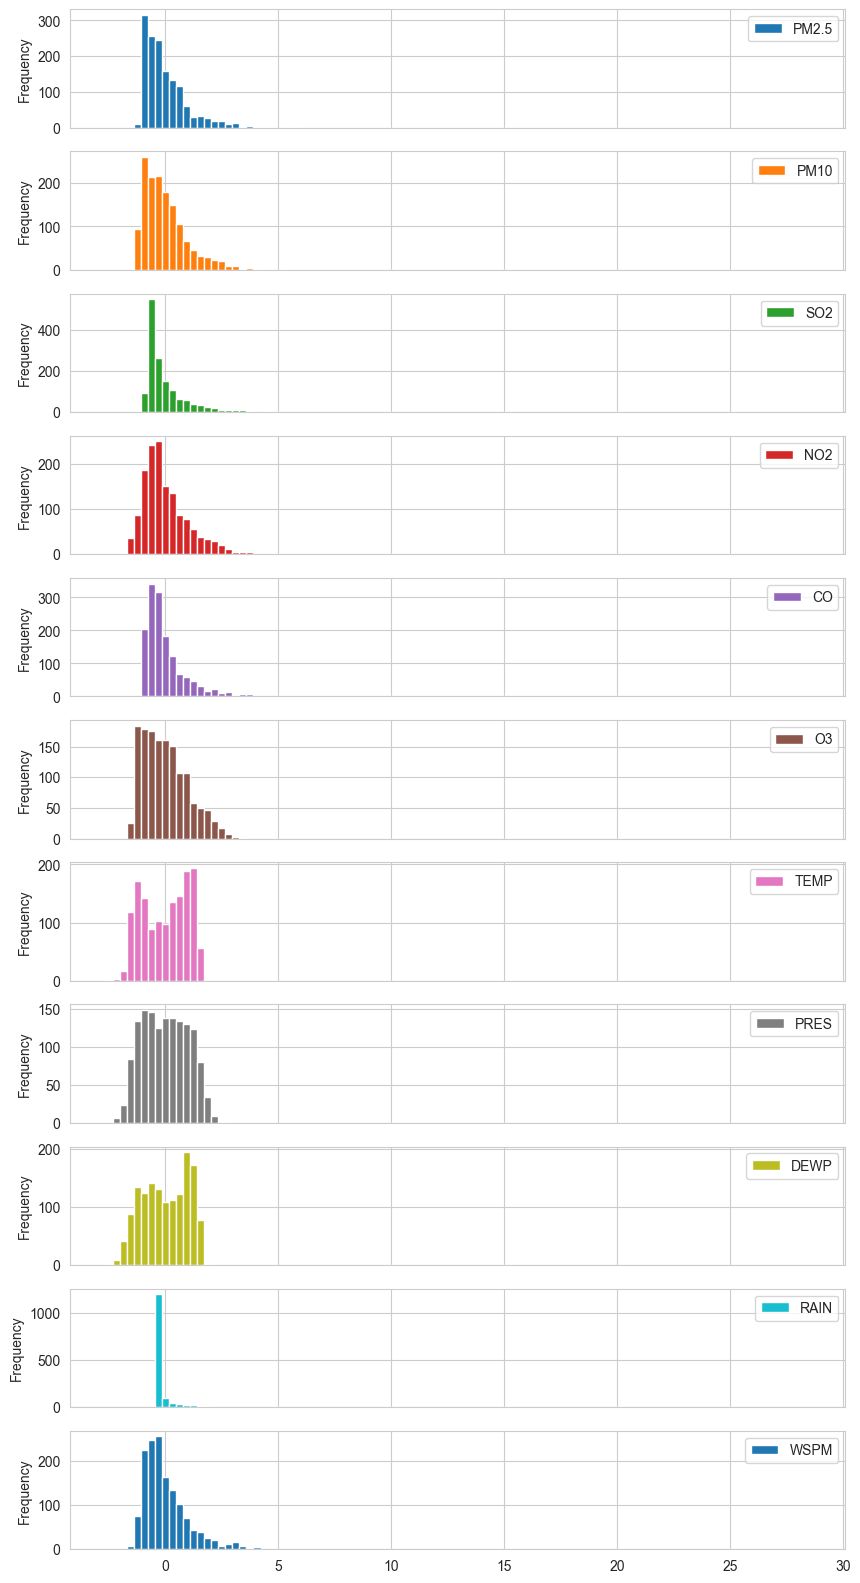

In [451]:
df_daily_scaled.plot.hist(subplots=True, figsize=(10, 20), bins=100)

array([[<Axes: xlabel='PM2.5', ylabel='PM2.5'>,
        <Axes: xlabel='PM10', ylabel='PM2.5'>,
        <Axes: xlabel='SO2', ylabel='PM2.5'>,
        <Axes: xlabel='NO2', ylabel='PM2.5'>,
        <Axes: xlabel='CO', ylabel='PM2.5'>,
        <Axes: xlabel='O3', ylabel='PM2.5'>,
        <Axes: xlabel='TEMP', ylabel='PM2.5'>,
        <Axes: xlabel='PRES', ylabel='PM2.5'>,
        <Axes: xlabel='DEWP', ylabel='PM2.5'>,
        <Axes: xlabel='RAIN', ylabel='PM2.5'>,
        <Axes: xlabel='WSPM', ylabel='PM2.5'>],
       [<Axes: xlabel='PM2.5', ylabel='PM10'>,
        <Axes: xlabel='PM10', ylabel='PM10'>,
        <Axes: xlabel='SO2', ylabel='PM10'>,
        <Axes: xlabel='NO2', ylabel='PM10'>,
        <Axes: xlabel='CO', ylabel='PM10'>,
        <Axes: xlabel='O3', ylabel='PM10'>,
        <Axes: xlabel='TEMP', ylabel='PM10'>,
        <Axes: xlabel='PRES', ylabel='PM10'>,
        <Axes: xlabel='DEWP', ylabel='PM10'>,
        <Axes: xlabel='RAIN', ylabel='PM10'>,
        <Axes: xlabel='WSPM', yl

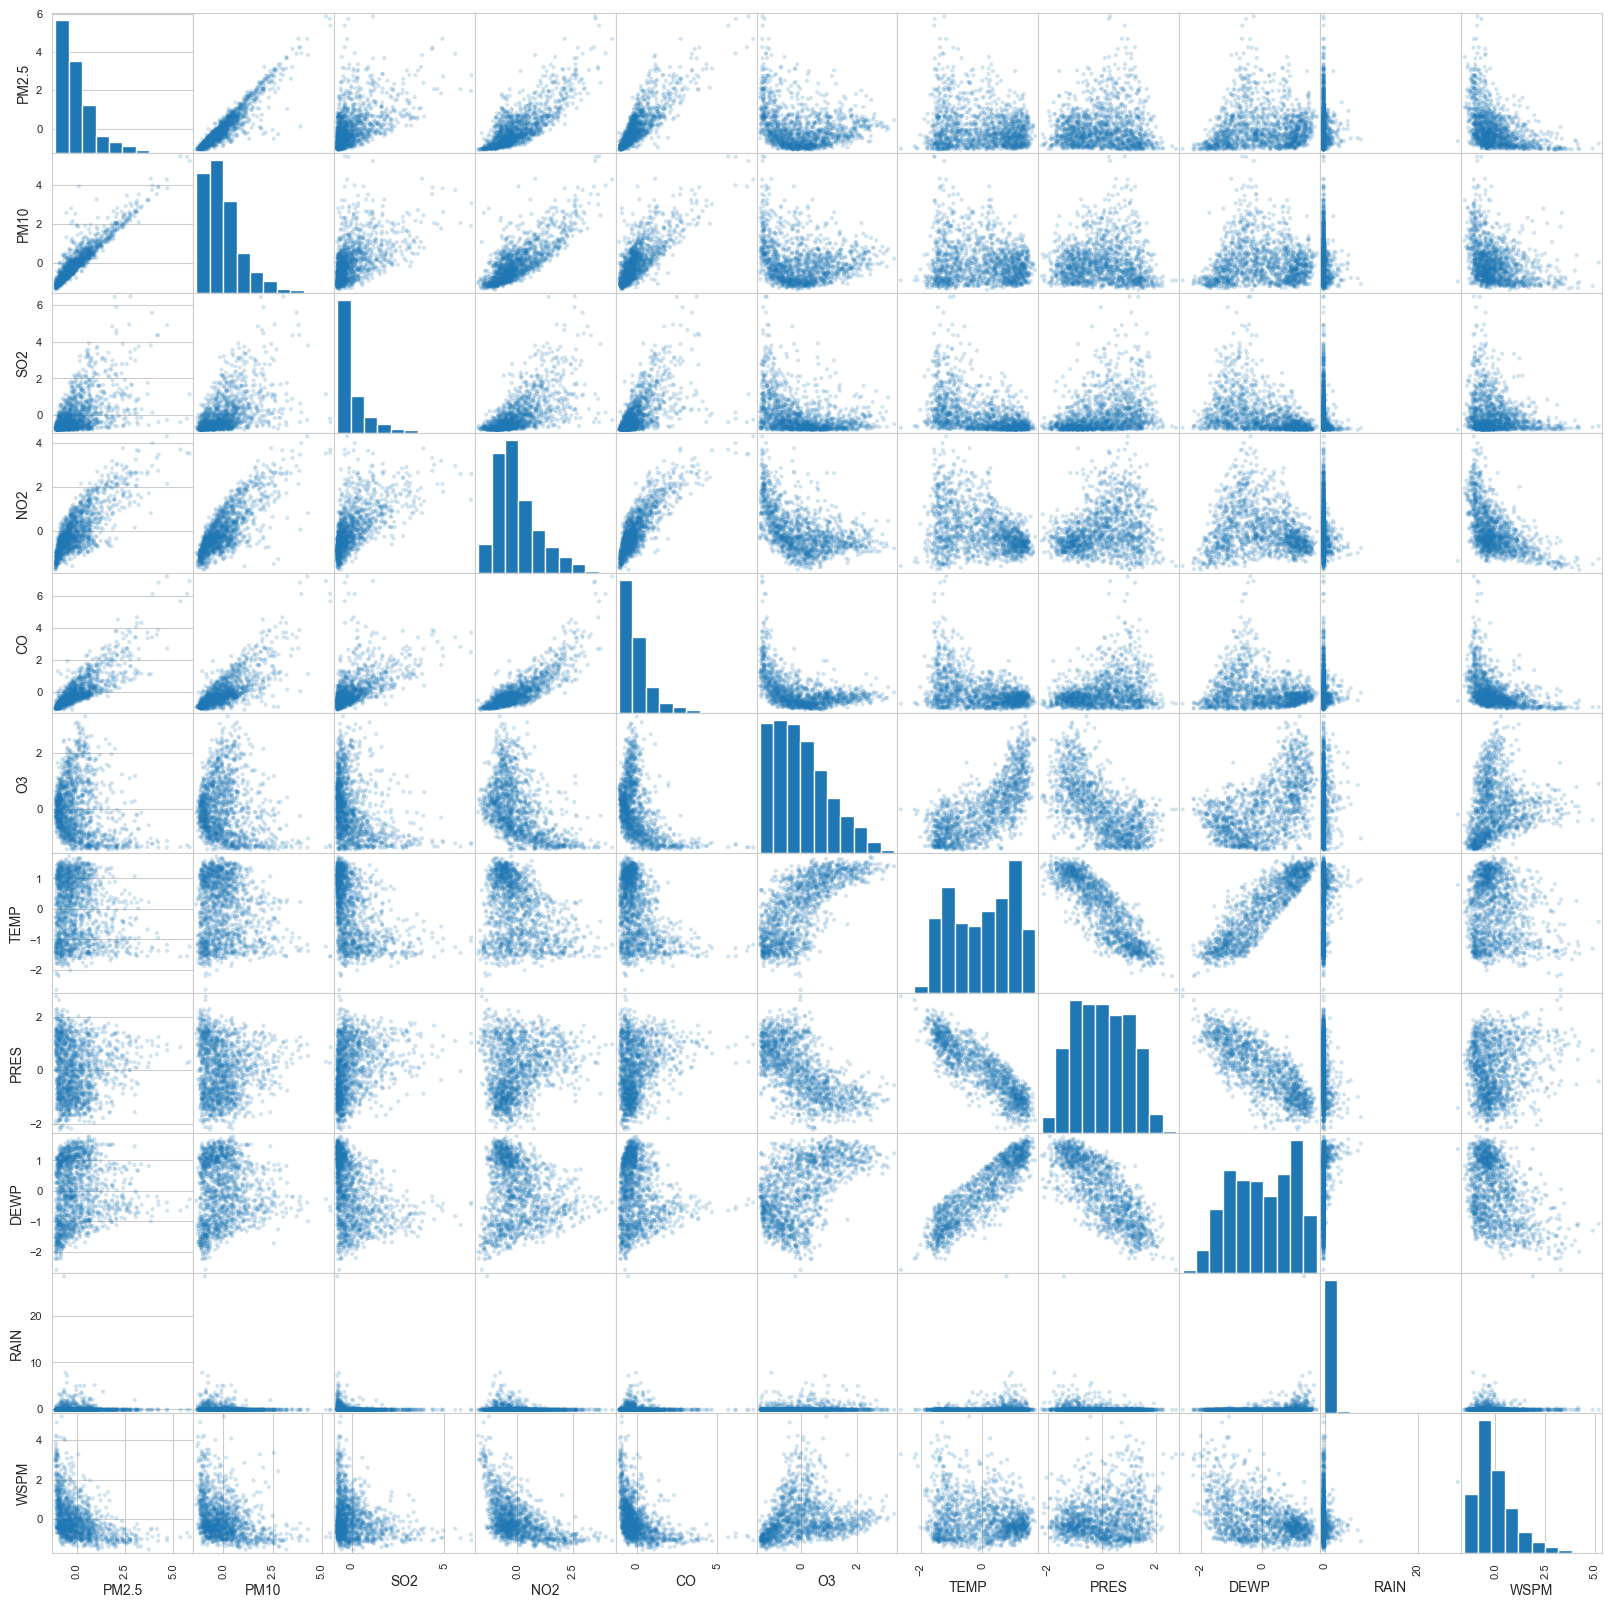

In [452]:
pd.plotting.scatter_matrix(df_daily_scaled, alpha=0.2, figsize=(20, 20))

# Feature Correlation

## Pearson Correlation

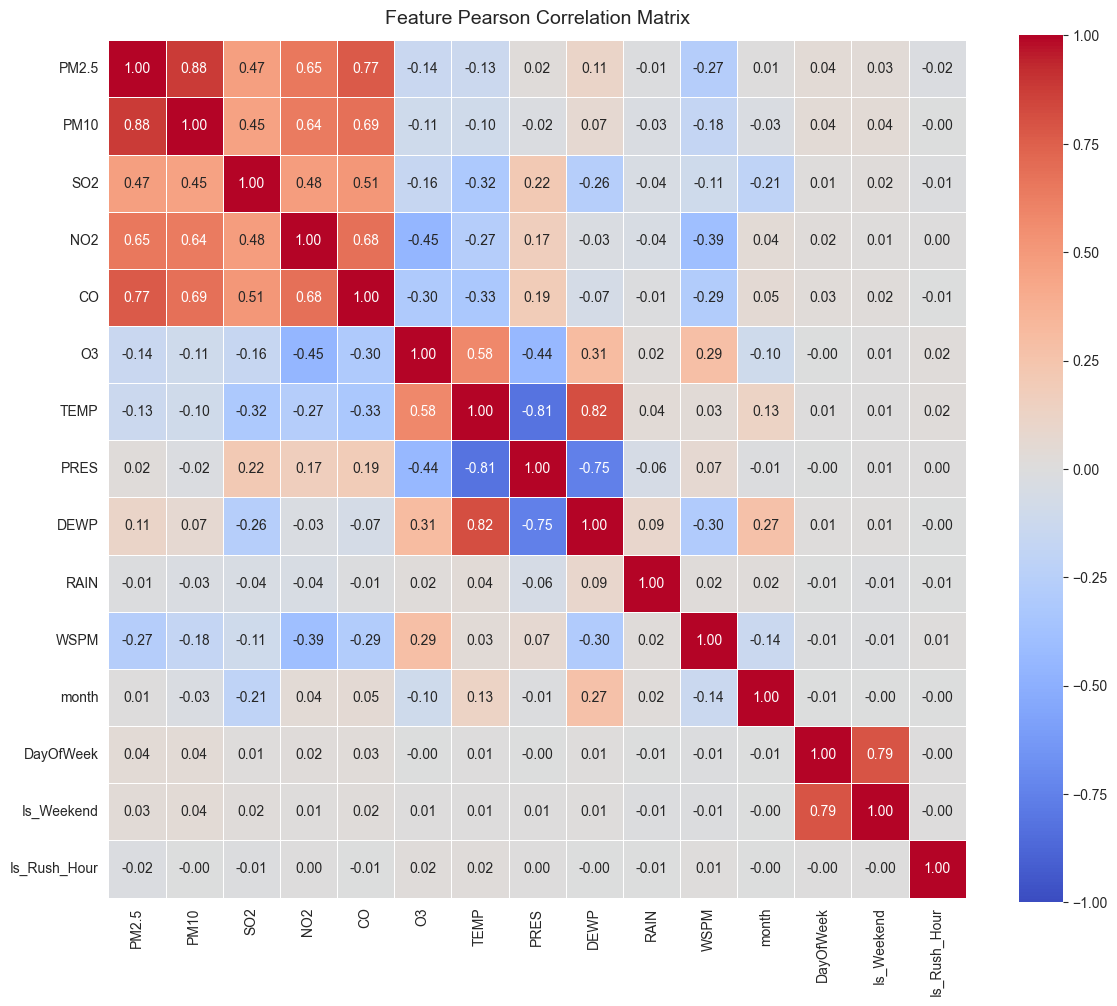

In [453]:
numeric_cols = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'month',
    'DayOfWeek', 'Is_Weekend', 'Is_Rush_Hour'
]

corr_matrix = df_all[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Pearson Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## Spearman Correlation

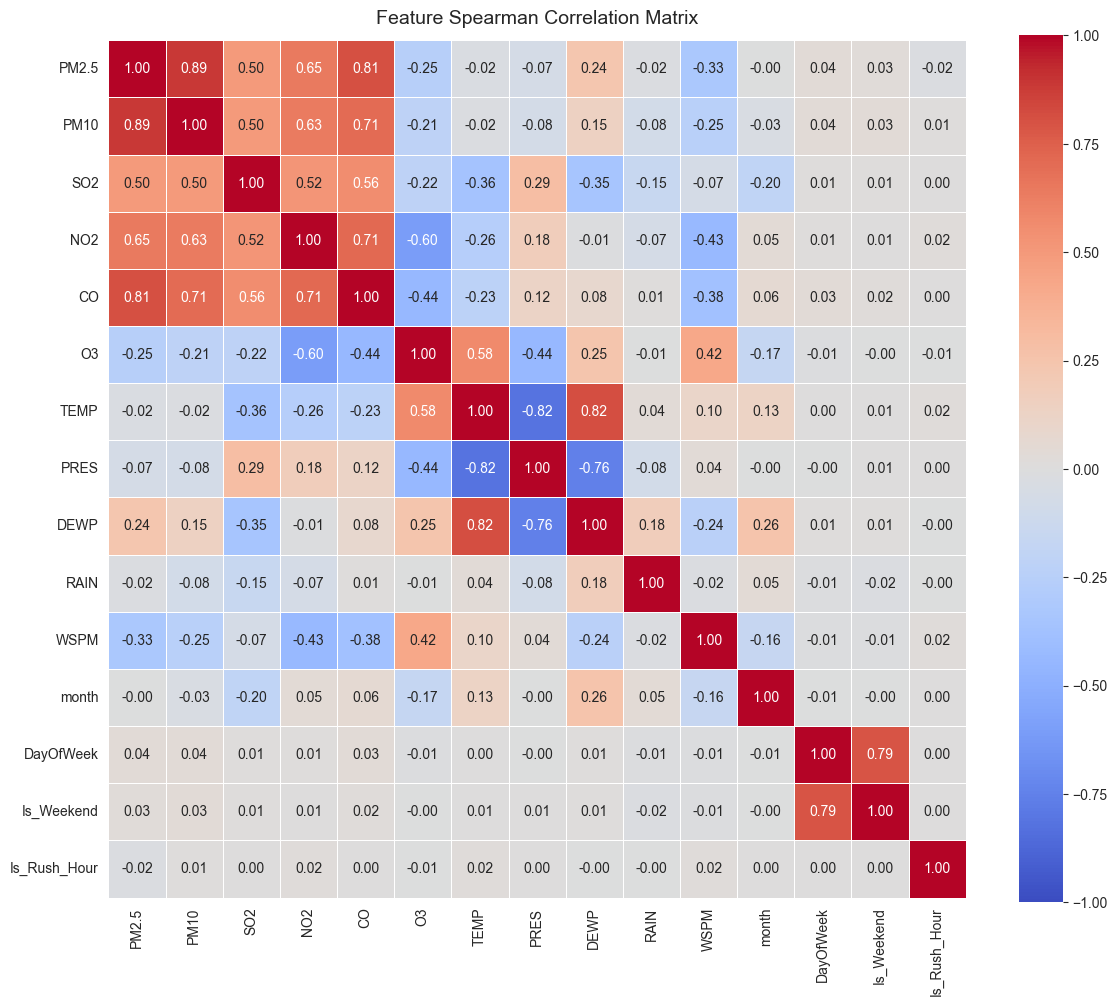

In [454]:
corr_matrix = df_all[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Spearman Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Time Series Decomposition


In [455]:
df_all[df_all['station'] == 'Aotizhongxin']["datetime"]

0       2013-03-01 00:00:00
1       2013-03-01 01:00:00
2       2013-03-01 02:00:00
3       2013-03-01 03:00:00
4       2013-03-01 04:00:00
                ...        
35059   2017-02-28 19:00:00
35060   2017-02-28 20:00:00
35061   2017-02-28 21:00:00
35062   2017-02-28 22:00:00
35063   2017-02-28 23:00:00
Name: datetime, Length: 35064, dtype: datetime64[us]

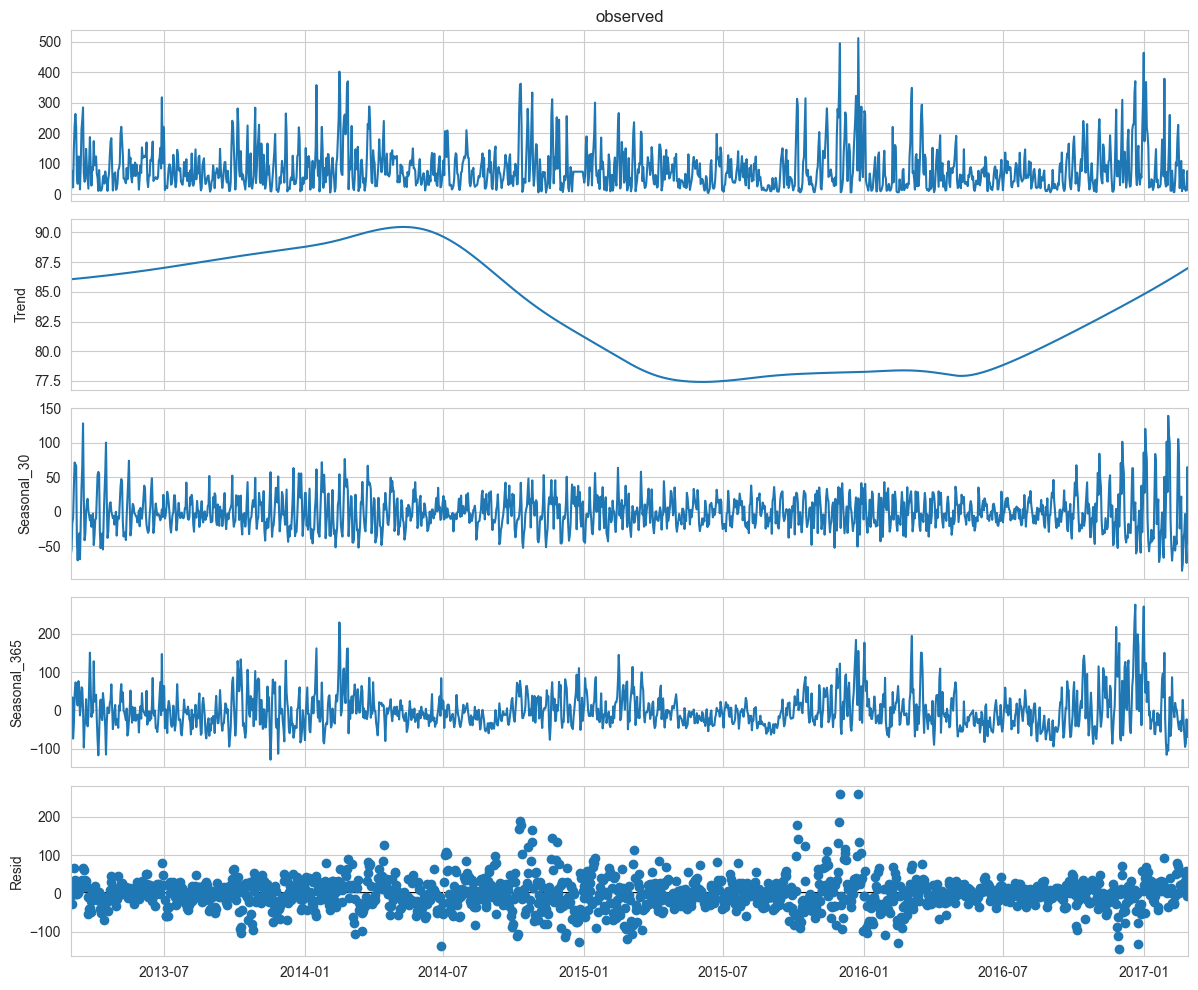

In [456]:
df_single_station = df_all[df_all['station'] == 'Aotizhongxin'].copy()
df_single_station.set_index("datetime", inplace=True)
df_daily = df_single_station['PM2.5'].resample('D').mean().dropna()

# Decompose with both monthly (30-day) and yearly (365-day) seasonal components
decomposition = MSTL(df_daily, periods=(30, 365)).fit()

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

# Baseline Models

## Naive Forecast, Moving Average Forecast, Seasonal Naive Forecast

In [457]:
grouped = df_all.groupby('station')['PM2.5']

# 1. Naive Forecast (Shift by 1 hour, grouped by station)
df_all['Naive_Forecast'] = grouped.shift(1)

# 2. Moving Average Forecast (3-hour rolling average, grouped by station)
df_all['Moving_Avg_Forecast'] = grouped.transform(lambda x: x.rolling(window=3).mean().shift(1))

# 3. Seasonal Naive Forecast (Shift by 24 hours, grouped by station)
df_all['Seasonal_Naive_Forecast'] = grouped.shift(24)

df_all['Is_Hazardous'] = (df_all['PM2.5'] > 75).astype(int)
df_all['Naive_Is_Hazardous'] = (df_all['Naive_Forecast'] > 75).astype(int)
df_all['Moving_Avg_Is_Hazardous'] = (df_all['Moving_Avg_Forecast'] > 75).astype(int)
df_all['Seasonal_Naive_Is_Hazardous'] = (df_all['Seasonal_Naive_Forecast'] > 75).astype(int)

In [458]:
# 1. Isolate one station and make sure it's sorted chronologically
df_station = df_all[df_all['station'] == 'Aotizhongxin'].copy()
df_station = df_station.sort_values('datetime').reset_index(drop=True)

# 2. Set up lists to store the MAE for each horizon (1 to 24)
horizons = range(1, 25)
mae_naive, mae_ma, mae_seasonal = [], [], []

# 3. Loop through each hour in the future
for h in horizons:

    # The Ground Truth: Shift the PM2.5 column UP by 'h' rows to represent the future
    y_true = df_station['PM2.5'].shift(-h)

    # Baseline 1: Naive (Predict the current hour's value for the future)
    y_pred_naive = df_station['PM2.5']

    # Baseline 2: 3-Hour Moving Average (Predict the current average for the future)
    y_pred_ma = df_station['PM2.5'].rolling(window=3).mean()

    # Baseline 3: Seasonal Naive
    # To predict 'h' hours ahead, we look at what happened exactly 24 hours before that target time.
    y_pred_seasonal = df_station['PM2.5'].shift(24 - h)

    # Create a temporary dataframe to easily drop NAs created by all the shifting
    temp_df = pd.DataFrame({
        'True': y_true,
        'Naive': y_pred_naive,
        'MA': y_pred_ma,
        'Seasonal': y_pred_seasonal
    }).dropna()

    # Calculate and store the MAE for this specific horizon
    mae_naive.append(mean_absolute_error(temp_df['True'], temp_df['Naive']))
    mae_ma.append(mean_absolute_error(temp_df['True'], temp_df['MA']))
    mae_seasonal.append(mean_absolute_error(temp_df['True'], temp_df['Seasonal']))

    # (Optional: You could do the exact same thing here using mean_squared_error
    # wrapped in np.sqrt() to store RMSE!)

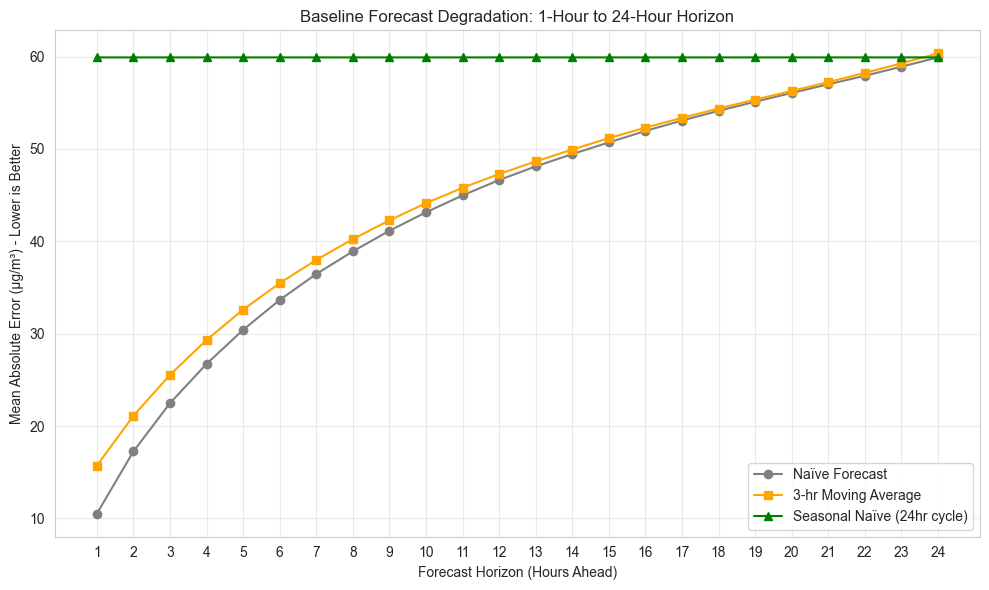

In [459]:
plt.figure(figsize=(10, 6))

# Plot the three error curves
plt.plot(horizons, mae_naive, label='Naïve Forecast', marker='o', color='gray')
plt.plot(horizons, mae_ma, label='3-hr Moving Average', marker='s', color='orange')
plt.plot(horizons, mae_seasonal, label='Seasonal Naïve (24hr cycle)', marker='^', color='green')

# Format the chart
plt.title('Baseline Forecast Degradation: 1-Hour to 24-Hour Horizon')
plt.xlabel('Forecast Horizon (Hours Ahead)')
plt.ylabel('Mean Absolute Error (µg/m³) - Lower is Better')
plt.xticks(horizons) # Force it to show 1 through 24 on the x-axis
plt.legend()
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [460]:
df_station

,station,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,...,Is_Rush_Hour,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos,Naive_Forecast,Moving_Avg_Forecast,Seasonal_Naive_Forecast
0,Aotizhongxin,1,2013,3,1,0,4.0,4.0,4.0,7.0,...,0,1.000000,6.123234e-17,-0.433884,-0.900969,0.000000,1.000000,NaN,NaN,NaN
1,Aotizhongxin,2,2013,3,1,1,8.0,8.0,4.0,7.0,...,0,1.000000,6.123234e-17,-0.433884,-0.900969,0.258819,0.965926,4.0,NaN,NaN
2,Aotizhongxin,3,2013,3,1,2,7.0,7.0,5.0,10.0,...,0,1.000000,6.123234e-17,-0.433884,-0.900969,0.500000,0.866025,8.0,NaN,NaN
3,Aotizhongxin,4,2013,3,1,3,6.0,6.0,11.0,11.0,...,0,1.000000,6.123234e-17,-0.433884,-0.900969,0.707107,0.707107,7.0,6.333333,NaN
4,Aotizhongxin,5,2013,3,1,4,3.0,3.0,12.0,12.0,...,0,1.000000,6.123234e-17,-0.433884,-0.900969,0.866025,0.500000,6.0,7.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,Aotizhongxin,35060,2017,2,28,19,12.0,29.0,5.0,35.0,...,1,0.866025,5.000000e-01,0.781831,0.623490,-0.965926,0.258819,13.0,12.333333,51.0
35060,Aotizhongxin,35061,2017,2,28,20,13.0,37.0,7.0,45.0,...,0,0.866025,5.000000e-01,0.781831,0.623490,-0.866025,0.500000,12.0,12.333333,51.0
35061,Aotizhongxin,35062,2017,2,28,21,16.0,37.0,10.0,66.0,...,0,0.866025,5.000000e-01,0.781831,0.623490,-0.707107,0.707107,13.0,12.666667,53.0
35062,Aotizhongxin,35063,2017,2,28,22,21.0,44.0,12.0,87.0,...,0,0.866025,5.000000e-01,0.781831,0.623490,-0.500000,0.866025,16.0,13.666667,58.0


## StatsForecast Models

In [461]:
from statsforecast import StatsForecast

horizon = 24 # 24 hour period

models = [Naive(), HistoricAverage(), WindowAverage(window_size=24), SeasonalNaive(season_length=24)]

sf = StatsForecast(models=models, freq='h')
sf.fit(df_station, id_col="station", time_col='datetime', target_col="PM2.5")
preds = sf.predict(h=horizon)

In [462]:
preds.head()

,station,datetime,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,Aotizhongxin,2017-03-01 00:00:00,19.0,83.163652,13.166667,56.0
1,Aotizhongxin,2017-03-01 01:00:00,19.0,83.163652,13.166667,15.0
2,Aotizhongxin,2017-03-01 02:00:00,19.0,83.163652,13.166667,9.0
3,Aotizhongxin,2017-03-01 03:00:00,19.0,83.163652,13.166667,7.0
4,Aotizhongxin,2017-03-01 04:00:00,19.0,83.163652,13.166667,13.0


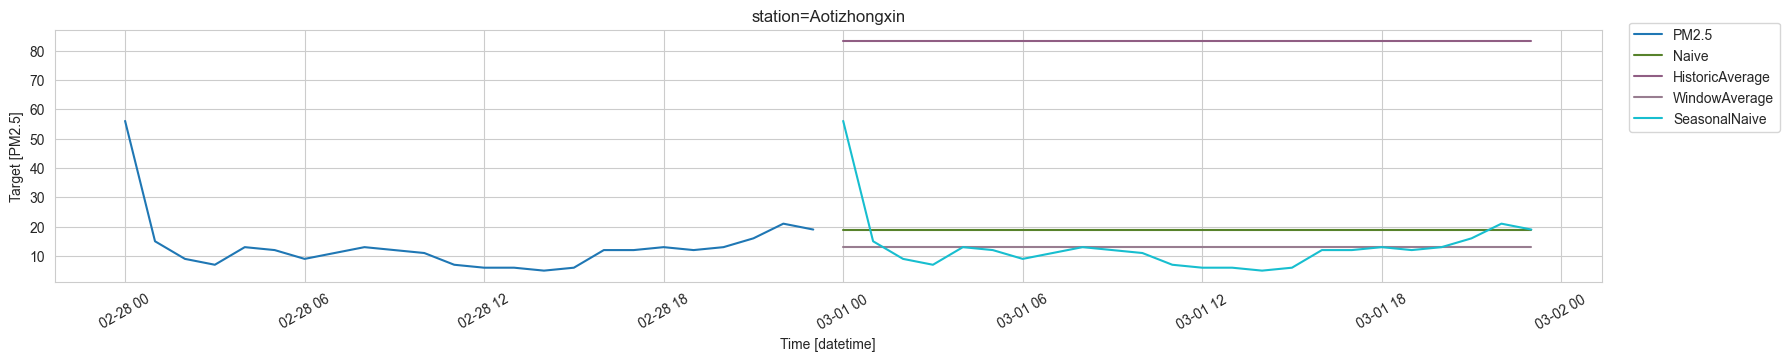

In [463]:
plot_series(df_station, forecasts_df=preds, max_insample_length=24, id_col="station", time_col='datetime', target_col="PM2.5")

In [464]:
categorical_columns = df_all.columns[df_all.dtypes == "category"]
print("Categorical features:", categorical_columns.tolist())

Categorical features: ['station', 'wd']


In [465]:
columns_to_drop = [col for col in df_all.columns.to_list() if col not in ["PM2.5","station","datetime"]]

In [466]:
test = df_all.drop(columns_to_drop, axis=1).groupby("station").tail(24)
train = df_all.drop(columns_to_drop, axis=1).drop(test.index).reset_index(drop=True)

In [467]:
sf.fit(df=train, id_col="station", time_col='datetime', target_col="PM2.5")

preds = sf.predict(h=horizon)

eval_df = pd.merge(test, preds, 'left', ['station', 'datetime'])

In [468]:
from utilsforecast.losses import mae
from utilsforecast.evaluation import evaluate

evaluation = evaluate(
    eval_df,
    metrics=[mae],
    id_col="station", time_col='datetime', target_col="PM2.5"
)
evaluation.head()

,station,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,Aotizhongxin,mae,56.833333,70.044929,62.958333,64.458333
1,Changping,mae,6.916667,56.825006,36.916667,37.916667
2,Dingling,mae,5.458333,54.342052,39.208333,39.708333
3,Dongsi,mae,49.500000,70.191670,67.375000,69.125000
4,Guanyuan,mae,38.750000,53.833870,45.958333,50.291667


In [469]:
evaluation = evaluation.drop(['station'], axis=1).groupby('metric').mean().reset_index()

In [470]:
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,37.006944,63.701012,52.505787,53.909722


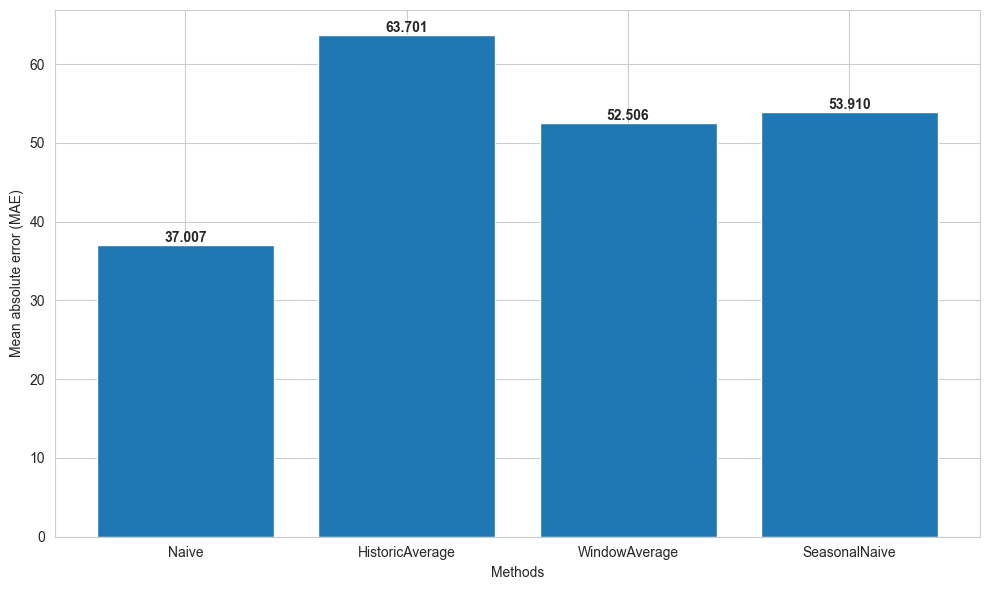

In [471]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

# Extreme Values

The processing of extreme values is also crucial. For example, when collecting data from sensors, some natural disasters and human factors might cause errors in the data sensors’ collection. Suppose these extreme values are put into the neural network for training together with the dataset. In that case, it will render the machine learning process with the wrong features, thus resulting in poor prediction performance. Therefore, to avoid the adverse effects of extreme values on machine learning training, the extreme values of the dataset were **deleted by observing each data in the dataset and setting the maximum and minimum values.** If the value in the dataset exceeds the setting value, the record will be flagged.

Winsorizing- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mstats.winsorize.html

Source: https://www.mdpi.com/2071-1050/14/4/2068

In [472]:
def flag_extremes_3sigma(df, features, group_by='station'):
    """
    Flags extreme values using the 3σ method per station.
    Retains data within (μ - 3σ, μ + 3σ), lower limit clipped to 0.
    Returns the cleaned df and a summary of flagged records.
    """
    df = df.copy()
    summary = []

    for feature in features:
        lower_col = f'{feature}_lower'
        upper_col = f'{feature}_upper'
        flag_col  = f'{feature}_extreme'

        # Compute μ and σ per station
        stats = df.groupby(group_by)[feature].agg(['mean', 'std'])
        df = df.join(stats, on=group_by, rsuffix='_stat')

        df[lower_col] = (df['mean'] - 3 * df['std']).clip(lower=0)  # floor at 0
        df[upper_col] =  df['mean'] + 3 * df['std']

        # Flag extremes
        df[flag_col] = (
            (df[feature] < df[lower_col]) |
            (df[feature] > df[upper_col])
        )

        n_flagged = df[flag_col].sum()
        pct       = 100 * n_flagged / len(df)
        summary.append({
            'Feature':   feature,
            'μ (global)': df[feature].mean(),
            'σ (global)': df[feature].std(),
            'Lower limit': df[lower_col].mean(),
            'Upper limit': df[upper_col].mean(),
            'Flagged':    n_flagged,
            'Flagged (%)': pct,
        })

        df.drop(columns=['mean', 'std'], inplace=True)

    return df, pd.DataFrame(summary).set_index('Feature')



In [473]:
# ── Apply ─────────────────────────────────────────────────────────────────────
POLLUTANTS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

df_all, extreme_summary = flag_extremes_3sigma(df_all, POLLUTANTS)

print("Extreme Value Summary (3σ method):")
print(extreme_summary.to_string(float_format='{:.2f}'.format))


Extreme Value Summary (3σ method):
         μ (global)  σ (global)  Lower limit  Upper limit  Flagged  Flagged (%)
Feature                                                                        
PM2.5         80.15       81.30         0.00       322.81     7604         1.81
PM10         105.06       92.67         0.00       381.03     6640         1.58
SO2           15.93       22.28         0.00        81.82     9334         2.22
NO2           50.53       35.31         0.00       150.52     4462         1.06
CO          1240.24     1170.86         0.00      4709.38     8812         2.09
O3            57.44       58.31         0.00       231.33     6922         1.65


In [474]:
# ── Remove flagged rows ───────────────────────────────────────────────────────
flag_cols   = [f'{f}_extreme' for f in POLLUTANTS]
any_extreme = df_all[flag_cols].any(axis=1)

print(f"\nTotal rows flagged (any feature): {any_extreme.sum()} "
      f"({100 * any_extreme.mean():.2f}%)")

df_clean = df_all[~any_extreme].copy()
print(f"Rows remaining after removal:     {len(df_clean)}")


Total rows flagged (any feature): 29189 (6.94%)
Rows remaining after removal:     391579


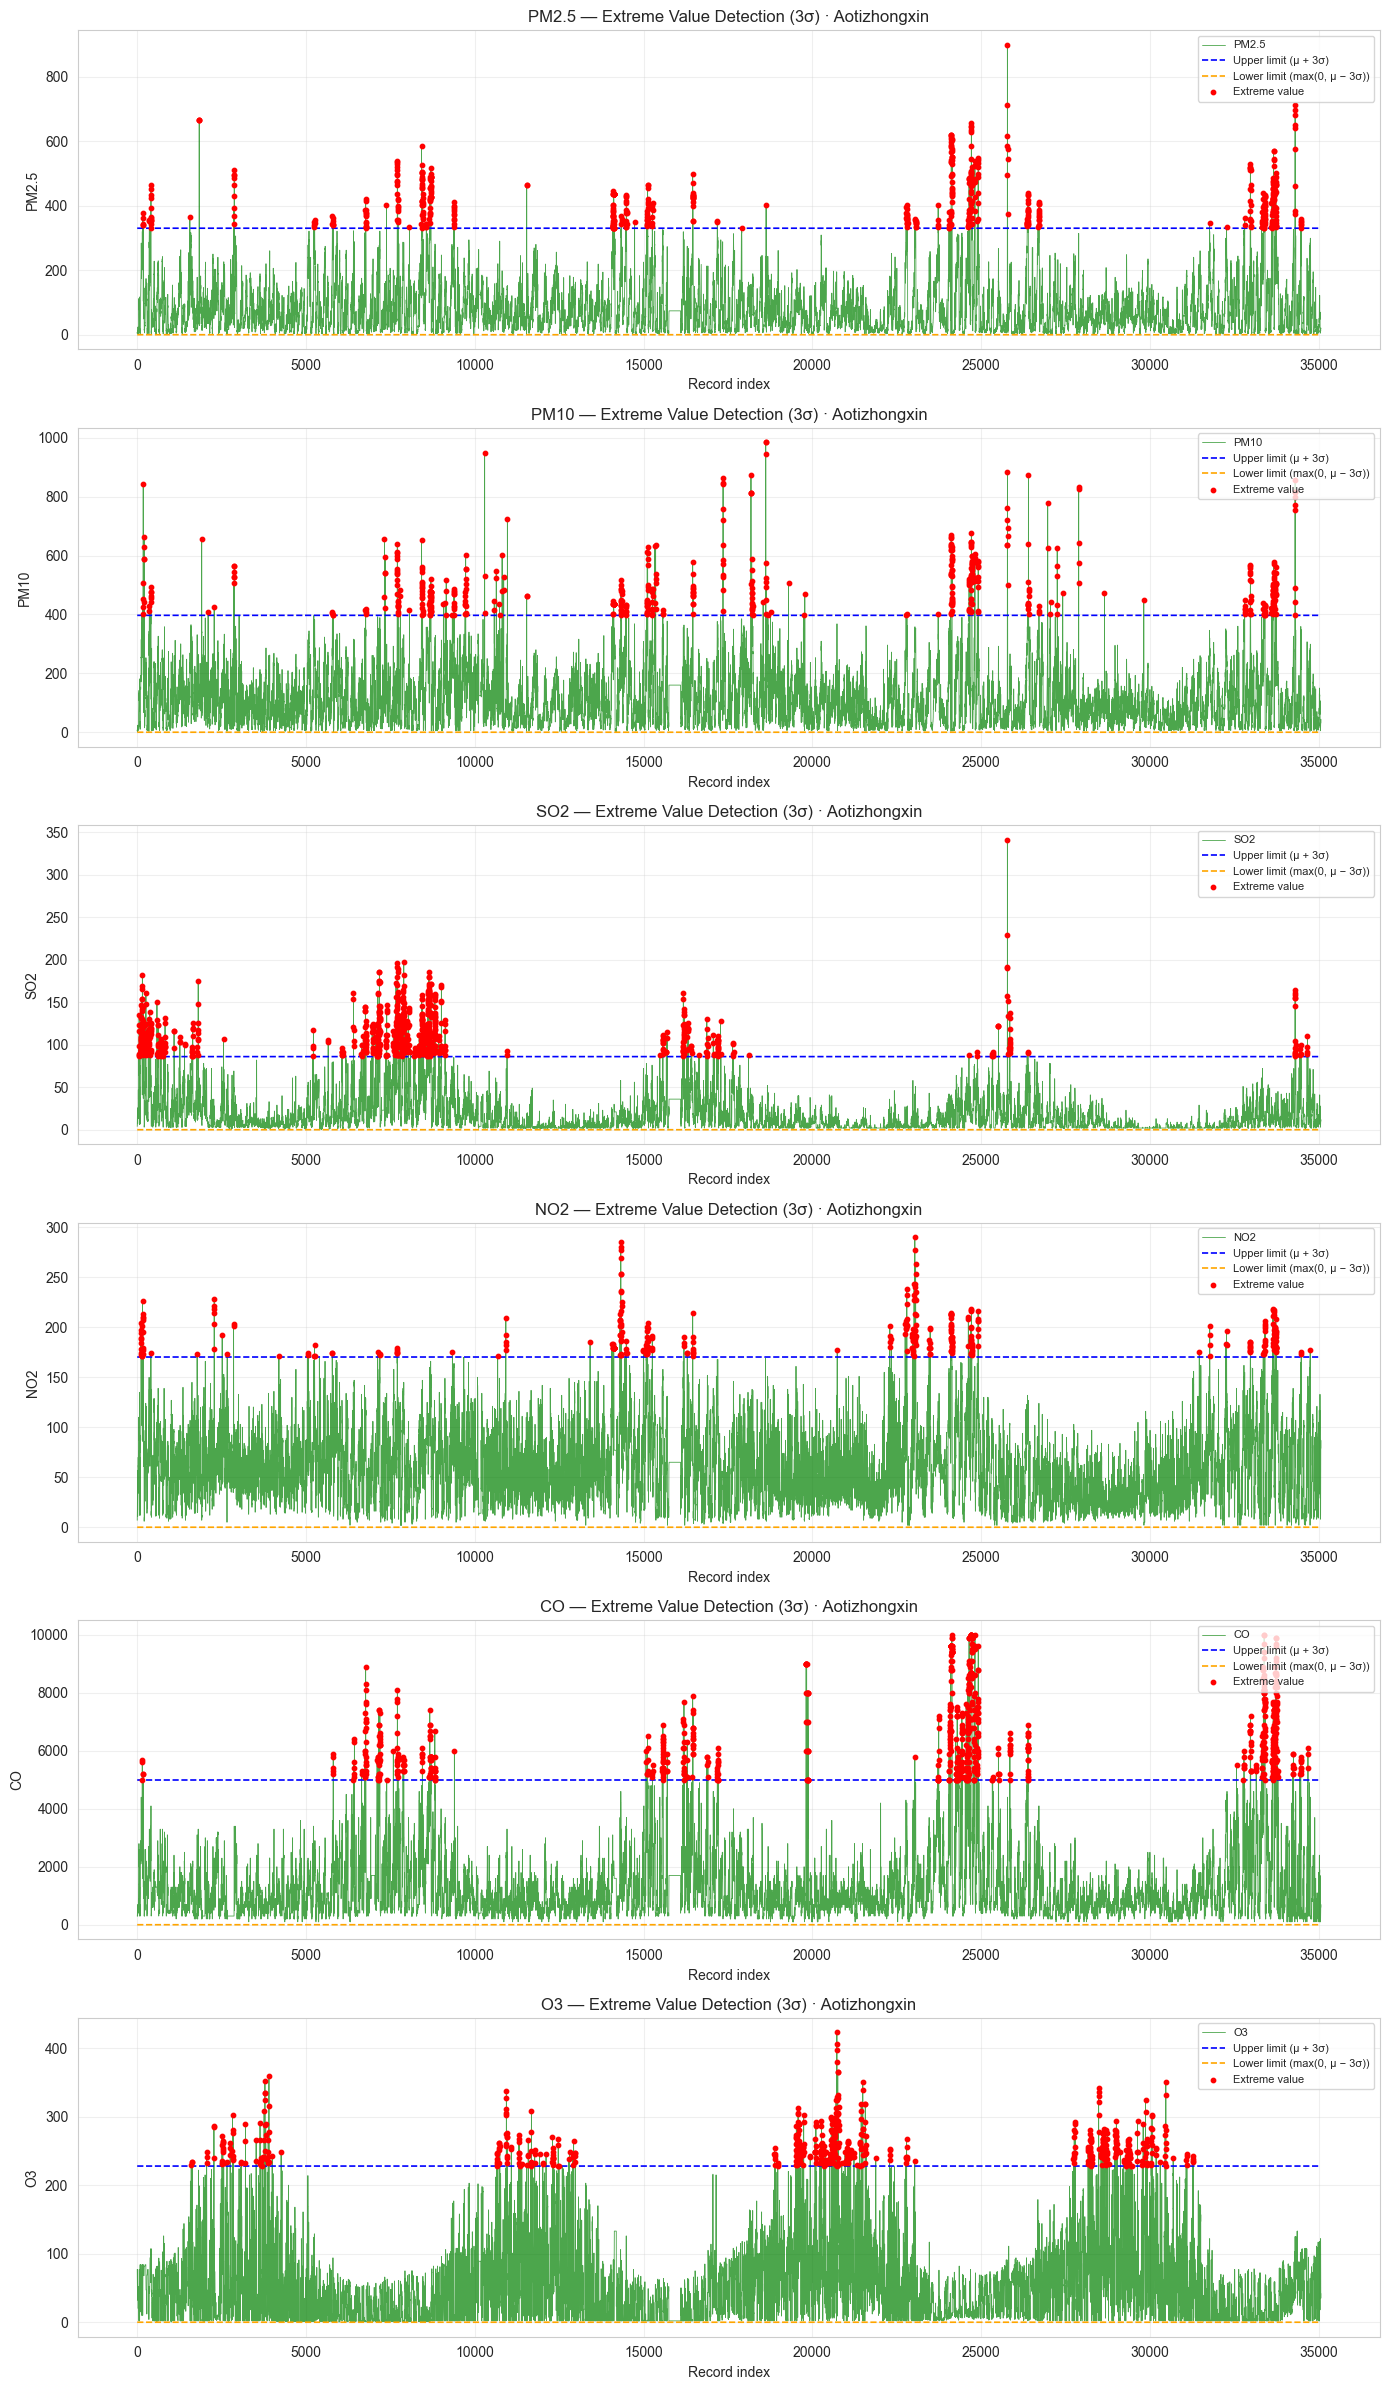

In [475]:
# ── Plot — replicates Figure 4 from the paper ─────────────────────────────────
fig, axes = plt.subplots(len(POLLUTANTS), 1, figsize=(14, 4 * len(POLLUTANTS)))

for ax, feature in zip(axes, POLLUTANTS):
    station_df = df_all[df_all['station'] == 'Aotizhongxin'].copy()

    upper = station_df[f'{feature}_upper']
    lower = station_df[f'{feature}_lower']
    flags = station_df[f'{feature}_extreme']

    x = range(len(station_df))

    # Raw data — green polyline (matches paper)
    ax.plot(x, station_df[feature], color='green', linewidth=0.6,
            alpha=0.7, label=feature)

    # Upper limit — blue line (matches paper)
    ax.plot(x, upper, color='blue', linewidth=1.2,
            linestyle='--', label='Upper limit (μ + 3σ)')
    ax.plot(x, lower, color='orange', linewidth=1.2,
            linestyle='--', label='Lower limit (max(0, μ − 3σ))')

    # Highlight flagged points in red
    ax.scatter(
        [i for i, f in enumerate(flags) if f],
        station_df.loc[flags, feature],
        color='red', s=10, zorder=5, label='Extreme value'
    )

    ax.set_title(f'{feature} — Extreme Value Detection (3σ) · Aotizhongxin')
    ax.set_xlabel('Record index')
    ax.set_ylabel(feature)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Using Winsorizing to Replace Outliers

### Do I need to keep these features are not?

In [502]:
df_clean.drop(df_clean.filter(regex='_lower|_upper|_extreme').columns, axis=1, inplace=True)

# Time-based Cross-Validation

In [476]:
ts_cv = TimeSeriesSplit(
    n_splits=5,
    gap=48,
    max_train_size=10000,
    test_size=1000,
)

# Prep for Training

Rescale the target variable (PM2.5) to predict a relative demand so that the mean absolute error is more easily interpreted as a fraction of the maximum demand.

Note

The fit method of the models used in this notebook all minimizes the mean squared error to estimate the conditional mean. The absolute error, however, would estimate the conditional median.

Nevertheless, when reporting performance measures on the test set in the discussion, we choose to focus on the mean absolute error instead of the (root) mean squared error because it is more intuitive to interpret. Note, however, that in this study the best models for one metric are also the best ones in terms of the other metric.

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html


In [501]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 391579 entries, 0 to 420767
Data columns (total 49 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   station                  391579 non-null  category      
 1   No                       391579 non-null  int64         
 2   year                     391579 non-null  int64         
 3   month                    391579 non-null  int64         
 4   day                      391579 non-null  int64         
 5   hour                     391579 non-null  int64         
 6   PM2.5                    391579 non-null  float64       
 7   PM10                     391579 non-null  float64       
 8   SO2                      391579 non-null  float64       
 9   NO2                      391579 non-null  float64       
 10  CO                       391579 non-null  float64       
 11  O3                       391579 non-null  float64       
 12  TEMP                     391579 

In [512]:
# 1 & 2: Drop columns the model shouldn't see
columns_to_drop = ['datetime', 'Naive_Forecast', 'Moving_Avg_Forecast', 'Seasonal_Naive_Forecast']
                   # 'Is_Hazardous', 'Naive_Is_Hazardous', 'Moving_Avg_Is_Hazardous', 'Seasonal_Naive_Is_Hazardous']
df_model_ready = df_all.drop(columns=columns_to_drop)
df_model_ready.drop(df_model_ready.filter(regex='_lower|_upper|_extreme|lag').columns, axis=1, inplace=True)

In [513]:
df_model_ready.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 27 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   station       420768 non-null  category
 1   No            420768 non-null  int64   
 2   year          420768 non-null  int64   
 3   month         420768 non-null  int64   
 4   day           420768 non-null  int64   
 5   hour          420768 non-null  int64   
 6   PM2.5         420768 non-null  float64 
 7   PM10          420768 non-null  float64 
 8   SO2           420768 non-null  float64 
 9   NO2           420768 non-null  float64 
 10  CO            420768 non-null  float64 
 11  O3            420768 non-null  float64 
 12  TEMP          420768 non-null  float64 
 13  PRES          420768 non-null  float64 
 14  DEWP          420768 non-null  float64 
 15  RAIN          420768 non-null  float64 
 16  wd            420768 non-null  category
 17  WSPM          420768 non-null  float64 


# One-Hot Encoding for Wind Direction and Station + X & y

In [514]:
# 3: Convert text categories (Station Name and Wind Direction) into numbers
X = pd.get_dummies(df_model_ready, columns=['station', 'wd'], drop_first=True)
y = df_model_ready['PM2.5'] # / df_all["PM2.5"].max()

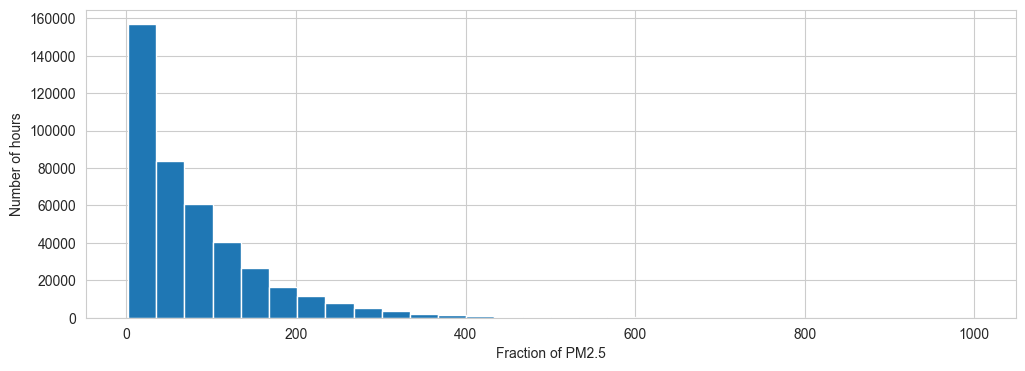

In [515]:
fig, ax = plt.subplots(figsize=(12, 4))
y.hist(bins=30, ax=ax)
_ = ax.set(
    xlabel="Fraction of PM2.5",
    ylabel="Number of hours",
)

# Dimensionality Reduction

In [480]:
# T-SNE Implementation
# X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)

In [481]:
# PCA Implementation
X_reduced_pca = PCA(n_components=2, random_state=69420).fit_transform(X.values)

In [482]:
# TruncatedSVD
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=69420).fit_transform(X.values)

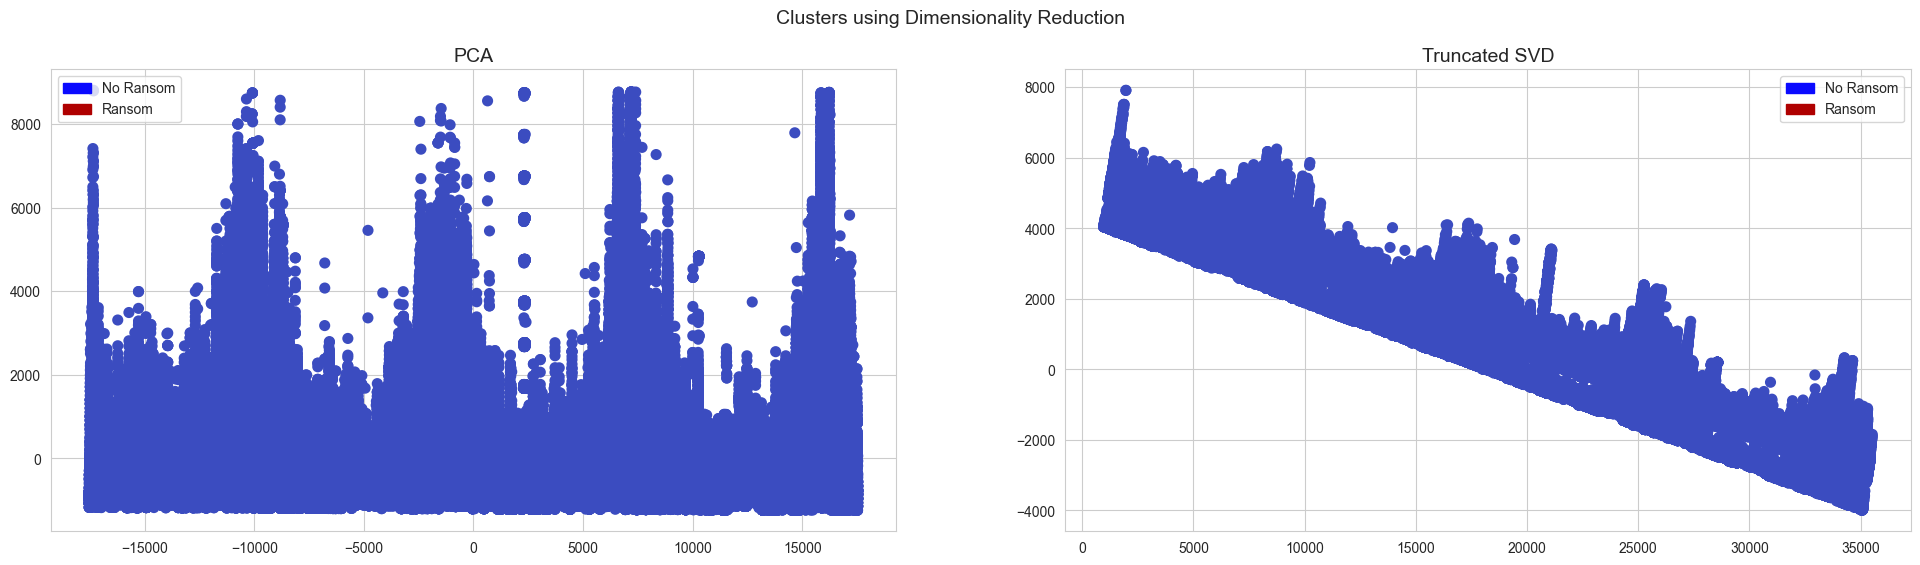

In [483]:
f, (ax2, ax3) = plt.subplots(1, 2, figsize=(24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpl.patches.Patch(color='#0A0AFF', label='No Ransom')
red_patch = mpl.patches.Patch(color='#AF0000', label='Ransom')


# t-SNE scatter plot
# ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Ransom', linewidths=2)
# ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Ransom', linewidths=2)
# ax1.set_title('t-SNE', fontsize=14)

# ax1.grid(True)

# ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', linewidths=2)
# ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=y, cmap='coolwarm', label='Ransom', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', linewidths=2)
# ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Ransom', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

# Time Lag Experiment

In [484]:
from scipy.stats import pearsonr
import warnings

# ── Config ────────────────────────────────────────────────────────────────────
TARGET    = 'PM2.5'                        # correlate against raw PM2.5
LAG_RANGE = range(1, 49)                   # test lags 1h → 48h
FEATURES  = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
             'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


In [485]:
# ── 1. Compute Pearson r at each lag for each feature ─────────────────────────
# Work on a single station to keep temporal ordering clean
df_station = df_all.copy()

results = []

for feature in FEATURES:
    for lag in LAG_RANGE:
        lagged  = df_station[feature].shift(lag)       # feature at time t-lag
        target  = df_station[TARGET]                   # PM2.5 at time t

        # Drop NaNs introduced by shift
        valid   = pd.concat([lagged, target], axis=1).dropna()

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r, p = pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])

        results.append({
            'Feature': feature,
            'Lag (hours)': lag,
            'Pearson r': r,
            'p-value': p,
            'Significant': p < 0.05
        })

results_df = pd.DataFrame(results)


In [486]:
# ── 2. Find optimal lag per feature (highest |r|) ─────────────────────────────
best_lags = (
    results_df.loc[results_df.groupby('Feature')['Pearson r']
                              .apply(lambda x: x.abs().idxmax())]
    .sort_values('Pearson r', ascending=False)
    .reset_index(drop=True)
)
print("Optimal lag per feature:")
print(best_lags[['Feature', 'Lag (hours)', 'Pearson r', 'p-value']].to_string(index=False))


Optimal lag per feature:
Feature  Lag (hours)  Pearson r       p-value
  PM2.5            1   0.968272  0.000000e+00
   PM10            1   0.859205  0.000000e+00
     CO            1   0.757680  0.000000e+00
    NO2            1   0.654302  0.000000e+00
    SO2            1   0.464749  0.000000e+00
   PRES           48   0.196125  0.000000e+00
   DEWP            1   0.113121  0.000000e+00
   RAIN            4  -0.038320 1.756529e-136
     O3            1  -0.148035  0.000000e+00
   TEMP           44  -0.169966  0.000000e+00
   WSPM            3  -0.299092  0.000000e+00


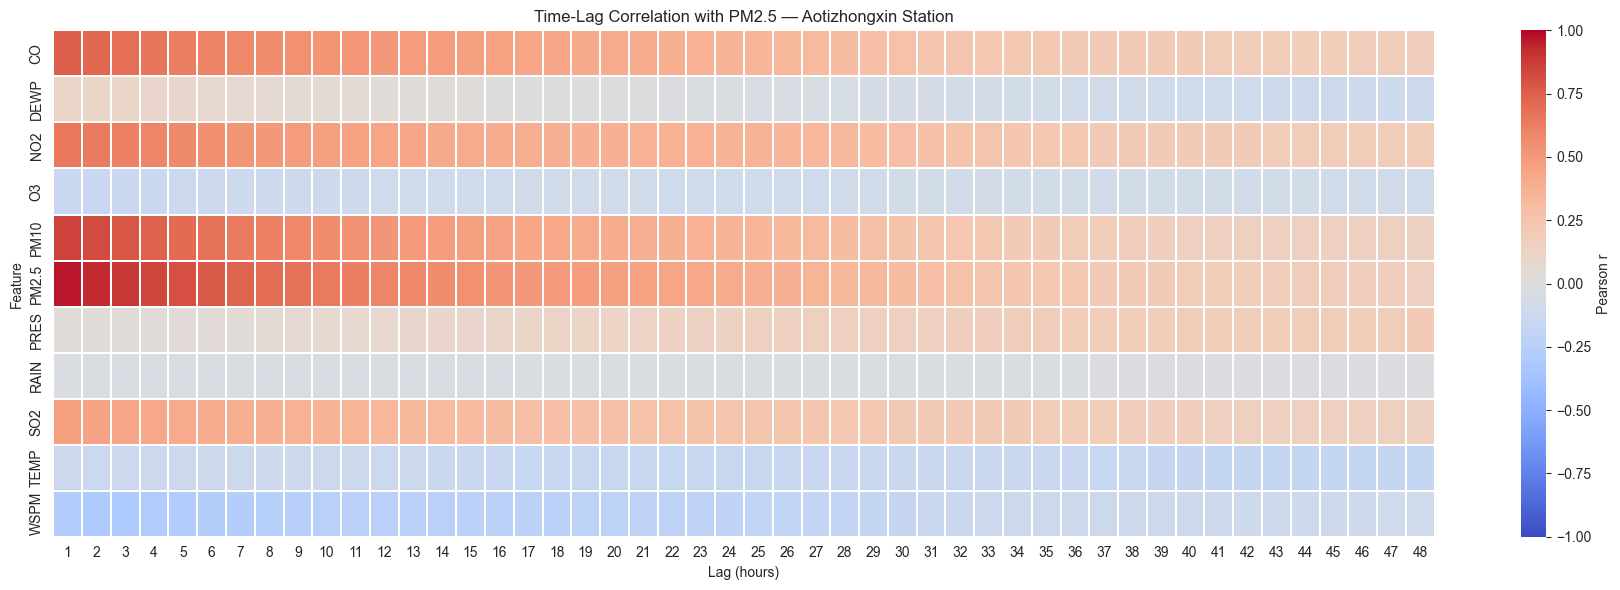

In [487]:
# ── 3. Heatmap — Pearson r across all features and lags ──────────────────────
pivot = results_df.pivot(index='Feature', columns='Lag (hours)', values='Pearson r')

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    pivot,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.2, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title(f'Time-Lag Correlation with {TARGET} — Aotizhongxin Station')
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


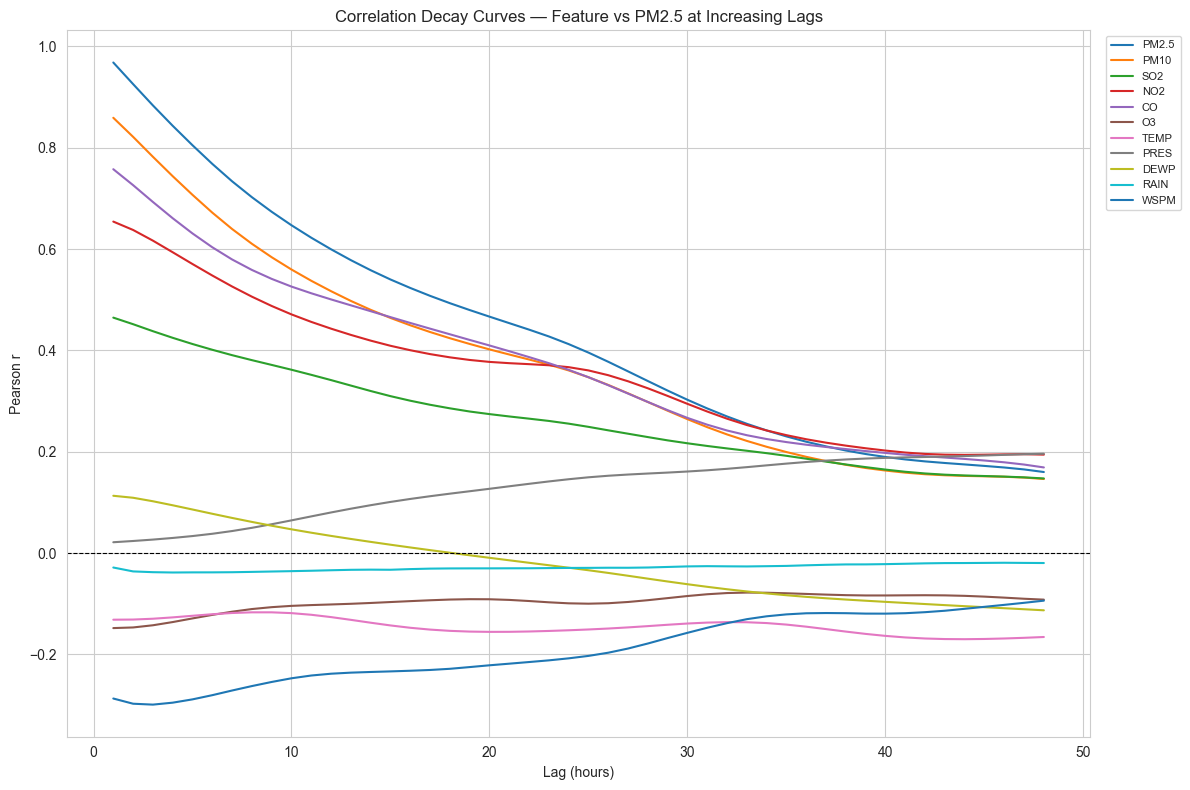

Added: PM2.5_lag1  (r=0.968)
Added: PM10_lag1  (r=0.859)
Added: CO_lag1  (r=0.758)
Added: NO2_lag1  (r=0.654)
Added: SO2_lag1  (r=0.465)
Added: PRES_lag48  (r=0.196)
Added: DEWP_lag1  (r=0.113)
Added: RAIN_lag4  (r=-0.038)
Added: O3_lag1  (r=-0.148)
Added: TEMP_lag44  (r=-0.170)
Added: WSPM_lag3  (r=-0.299)


In [488]:
# ── 4. Line plot — correlation decay curves per feature ──────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
for feature in FEATURES:
    subset = results_df[results_df['Feature'] == feature]
    ax.plot(subset['Lag (hours)'], subset['Pearson r'], label=feature, linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Pearson r')
ax.set_title(f'Correlation Decay Curves — Feature vs {TARGET} at Increasing Lags')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# ── 5. (Optional) Add optimal lag features back to the model ─────────────────
for _, row in best_lags.iterrows():
    feat    = row['Feature']
    optimal = int(row['Lag (hours)'])
    col     = f"{feat}_lag{optimal}"
    df_all[col] = df_all.groupby('station')[feat].shift(optimal)
    print(f"Added: {col}  (r={row['Pearson r']:.3f})")

## Pearson Correlation

## Spearman Correlation

# Feature Engineering

In [489]:
categorical_columns = df_all.columns[df_all.dtypes == "category"]

In [490]:
print("Categorical features:", categorical_columns.tolist())

Categorical features: ['station', 'wd']


In [518]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 51 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   No                     420768 non-null  int64  
 1   year                   420768 non-null  int64  
 2   month                  420768 non-null  int64  
 3   day                    420768 non-null  int64  
 4   hour                   420768 non-null  int64  
 5   PM2.5                  420768 non-null  float64
 6   PM10                   420768 non-null  float64
 7   SO2                    420768 non-null  float64
 8   NO2                    420768 non-null  float64
 9   CO                     420768 non-null  float64
 10  O3                     420768 non-null  float64
 11  TEMP                   420768 non-null  float64
 12  PRES                   420768 non-null  float64
 13  DEWP                   420768 non-null  float64
 14  RAIN                   420768 non-null  float64

In [519]:
y

0          4.0
1          8.0
2          7.0
3          6.0
4          3.0
          ... 
420763    11.0
420764    13.0
420765    14.0
420766    12.0
420767    13.0
Name: PM2.5, Length: 420768, dtype: float64

In [521]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV


alphas = np.logspace(-6, 6, 25)

cyclic_cossin_transformer = ColumnTransformer(
    transformers=[
        ("categorical", one_hot_encoder, categorical_columns),
        ("month_sin", sin_transformer(12), ["month"]),
        ("month_cos", cos_transformer(12), ["month"]),
        ("weekday_sin", sin_transformer(7), ["DayOfWeek"]),
        ("weekday_cos", cos_transformer(7), ["DayOfWeek"]),
        ("hour_sin", sin_transformer(24), ["hour"]),
        ("hour_cos", cos_transformer(24), ["hour"]),
    ],
    remainder=MinMaxScaler(),
)

cyclic_cossin_linear_pipeline = make_pipeline(
    # cyclic_cossin_transformer,
    RidgeCV(alphas=alphas),
)

tempX = df_model_ready[df_model_ready['station'] == 'Aotizhongxin'].copy()
tempy = tempX['PM2.5']

sklearnEvaluate(cyclic_cossin_linear_pipeline, tempX, tempy, cv=ts_cv)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/sklearn/pipelin

## Scale/Normalize The Data

https://www.tensorflow.org/tutorials/structured_data/time_series#normalize_the_data

In [275]:
def plotViolin(df, train_mean, train_std):
    df_std = (df - train_mean) / train_std
    df_std = df_std.melt(var_name='Column', value_name='Normalized')
    plt.figure(figsize=(12, 6))
    ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
    _ = ax.set_xticklabels(df.keys(), rotation=90)


In [276]:
def standardScale(x_train, x_test, y_train, y_test, df):
    train_mean = x_train.mean()
    train_std = x_train.std()

    X_train_scaled = (x_train - train_mean) / train_std
    # val_df = (val_df - train_mean) / train_std
    X_test_scaled = (x_test - train_mean) / train_std

    y_train_array = y_train.values
    y_test_array = y_test.values

    # plotViolin(df, train_mean, train_std)

    return X_train_scaled, X_test_scaled, y_train_array, y_test_array

In [277]:
def minMaxScale(X_train, X_test, y_train, y_test, df):
    train_mean = X_train.mean()
    train_std = X_train.std()

    X_train_scaled = (X_train - train_mean) / train_std
    # val_df = (val_df - train_mean) / train_std
    X_test_scaled = (X_test - train_mean) / train_std

    y_train_array = y_train.values
    y_test_array = y_test.values

    # plotViolin(df, train_mean, train_std)

    return X_train_scaled, X_test_scaled, y_train_array, y_test_array

# Histogram-based Gradient Boosting Regression Tree

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#gradient-boosting

In [278]:
gbrt = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=42)

In [279]:
sklearnEvaluate(gbrt, X, y, cv=ts_cv, model_prop="n_iter_")

Mean model.n_iter_ = 100.0
Mean Absolute Error:     14.301 +/- 2.617
Root Mean Squared Error: 21.895 +/- 5.617


# Random Forest Regressor

In [280]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

In [281]:
sklearnEvaluate(rf_model, X, y, cv=ts_cv)

Mean Absolute Error:     15.242 +/- 2.749
Root Mean Squared Error: 23.253 +/- 5.051


# Splitting the Data for Training, Test, Validation

the dataset was divided into a training set, test set, and validation set at a ratio of 6:2:2. source: https://www.mdpi.com/2071-1050/14/4/2068

The prediction time units used the multiple air-pollution factor values of the first 8, 16, and 24 h periods to predict the model’s input data. The output results were the PM2.5 concentration data for the next 8 h of the predicted period. source: https://www.mdpi.com/2071-1050/14/4/2068

# Normalization using Vectorization

# Deep Learning

# RNN, LSTM, CNN

In [530]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 51 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   No                     420768 non-null  int64  
 1   year                   420768 non-null  int64  
 2   month                  420768 non-null  int64  
 3   day                    420768 non-null  int64  
 4   hour                   420768 non-null  int64  
 5   PM2.5                  420768 non-null  float64
 6   PM10                   420768 non-null  float64
 7   SO2                    420768 non-null  float64
 8   NO2                    420768 non-null  float64
 9   CO                     420768 non-null  float64
 10  O3                     420768 non-null  float64
 11  TEMP                   420768 non-null  float64
 12  PRES                   420768 non-null  float64
 13  DEWP                   420768 non-null  float64
 14  RAIN                   420768 non-null  float64

In [531]:
WINDOW     = 24   # use the past 24 hours as context
THRESHOLD  = 75
BATCH_SIZE = 256
EPOCHS     = 30

# ── 2. Scale features (required for neural nets) ─────────────────────────────
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)


In [532]:
# ── 3. Build sliding windows ──────────────────────────────────────────────────
# Each sample becomes a (WINDOW, n_features) sequence
def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])   # shape: (window, n_features)
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y, WINDOW)
# X_seq shape: (n_samples, 24, n_features)

n_steps    = X_seq.shape[1]
n_features = X_seq.shape[2]

print("n_steps:", n_steps)
print("n_features:", n_features)

n_steps: 24
n_features: 51


In [533]:
# ── 4. Model definitions ──────────────────────────────────────────────────────
def build_rnn():
    m = Sequential()
    m.add(Input(shape=(n_steps, n_features)))
    m.add(SimpleRNN(64, return_sequences=False))
    m.add(Dropout(0.2))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

def build_lstm():
    m = Sequential()
    m.add(Input(shape=(n_steps, n_features)))
    m.add(LSTM(64, return_sequences=False))
    m.add(Dropout(0.2))
    m.add(Dense(1, activation='sigmoid'))

    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

def build_cnn():
    m = Sequential()
    m.add(Input(shape=(n_steps, n_features)))
    m.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    m.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    m.add(GlobalMaxPooling1D())
    m.add(Dropout(0.2))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

builders = {
    'RNN':  build_rnn,
    'LSTM': build_lstm,
    'CNN':  build_cnn,
}

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [534]:
# ── 5. Time-series CV ─────────────────────────────────────────────────────────
metric_keys = ['MAE', 'MSE', 'RMSE']
nn_metrics = {name: {m: [] for m in metric_keys} for name in builders}

for fold, (train_idx, test_idx) in enumerate(ts_cv.split(X_seq, y_seq), start=1):
    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_seq[train_idx], y_seq[test_idx]

    fold_summary = f"Fold {fold}"

    for name, build_fn in builders.items():
        model = build_fn()   # fresh model each fold
        print(model.summary())
        model.fit(
            X_train, y_train,
            validation_split=0.1,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=0
        )

        y_prob = model.predict(X_test, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)

        nn_metrics[name]['MAE'].append(mean_absolute_error(y_test, y_pred))
        nn_metrics[name]['MSE'].append(mean_squared_error(y_test, y_pred))
        nn_metrics[name]['RMSE'].append(root_mean_squared_error(y_test, y_pred))

        fold_summary += f" | {name} MAE: {nn_metrics[name]['MAE'][-1]:.3f}"
        fold_summary += f" | {name} MSE: {nn_metrics[name]['MSE'][-1]:.3f}"
        fold_summary += f" | {name} RMSE: {nn_metrics[name]['RMSE'][-1]:.3f}"
        fold_summary += '\n'

    print(fold_summary)


Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_27 (SimpleRNN)       │ (None, 64)             │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,489 (29.25 KB)

 Trainable params: 7,489 (29.25 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_58 (Conv1D)              │ (None, 22, 64)         │         9,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_59 (Conv1D)              │ (None, 20, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_29         │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_91 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,065 (62.75 KB)

 Trainable params: 16,065 (62.75 KB)

 Non-trainable params: 0 (0.00 B)

None
Fold 5 | RNN MAE: 83.292 | RNN MSE: 18118.296 | RNN RMSE: 134.604
 | LSTM MAE: 83.292 | LSTM MSE: 18118.296 | LSTM RMSE: 134.604
 | CNN MAE: 83.292 | CNN MSE: 18118.296 | CNN RMSE: 134.604



In [535]:
# ── 6. Merge with existing results and plot ───────────────────────────────────
nn_results_df = pd.DataFrame({
    name: {m: np.mean(v) for m, v in metrics.items()}
    for name, metrics in nn_metrics.items()
}).T

all_results_df = pd.concat([results_df, nn_results_df]).sort_values('M', ascending=False)

print("\nFull model comparison:")
print(all_results_df.to_string(float_format='{:.3f}'.format))

all_results_df.plot(kind='bar', figsize=(12, 5), ylim=(0, 1), rot=20)
plt.title('All Models — 24h Ahead Forecast (Time-Series CV)')
plt.ylabel('Score (averaged across folds)')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 2223, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
        etype, value, tb, tb_offset=tb_offset
    )
  File "/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/IPython/core/ultratb.py", line 1228, in structured_traceback
    return FormattedTB.structured_traceback(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        self, etype, evalue, etb, tb_offset, context
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/Users/darronporter/Downloads/COMP4030 Data Science & Machine Learning/Coursework/.venv/lib/python3.13/site-packages/IPython/core/ultratb.py", line 1099, in structured_traceback
    return VerboseTB.structured_traceback(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        

# Overfitting

In [128]:
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.layers import BatchNormalization


In [297]:
# ── Experiment variants ───────────────────────────────────────────────────────
def build_baseline():
    """Large network, no regularization — expected to overfit"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True),
        LSTM(64),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_reduced():
    """Smaller network — fewer parameters = less capacity to memorise"""
    m = Sequential([
        LSTM(32, input_shape=(n_steps, n_features)),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_l1_l2():
    """Full size + L1/L2 weight penalties on LSTM kernel and recurrent kernel"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True,
             kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3),
             recurrent_regularizer=l2(1e-3)),
        LSTM(64,
             kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3)),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_dropout():
    """Full size + dropout on outputs and recurrent connections"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True,
             dropout=0.3,              # drops input/output connections
             recurrent_dropout=0.2),   # drops recurrent connections
        LSTM(64,
             dropout=0.3,
             recurrent_dropout=0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

In [298]:

variants = {
    'Baseline (no reg)': build_baseline,
    'Reduced Size':      build_reduced,
    'L1 + L2':           build_l1_l2,
    'Dropout':           build_dropout,
}

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [299]:
# ── Run experiment: one fold only for speed, use last fold for fair comparison ─
train_idx, test_idx = list(ts_cv.split(X_seq, y_seq))[-1]   # final fold
X_train_e, X_test_e = X_seq[train_idx], X_seq[test_idx]
y_train_e, y_test_e = y_seq[train_idx], y_seq[test_idx]

histories   = {}
exp_results = {}

for name, build_fn in variants.items():
    print(f"\nTraining: {name}")
    model = build_fn()

    history = model.fit(
        X_train_e, y_train_e,
        validation_split=0.15,
        epochs=60,
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )
    histories[name] = history.history

    y_pred = (model.predict(X_test_e, verbose=0).flatten() > 0.5).astype(int)
    exp_results[name] = {
        'F1':        f1_score(y_test_e, y_pred),
        'Precision': precision_score(y_test_e, y_pred),
        'Recall':    recall_score(y_test_e, y_pred),
        'Accuracy':  accuracy_score(y_test_e, y_pred),
        'Best epoch': len(history.history['loss']),    # epochs before early stop
        'Train loss': min(history.history['loss']),
        'Val loss':   min(history.history['val_loss']),
    }



Training: Baseline (no reg)


NameError: name 'Input' is not defined


Overfitting Experiment Results:
                     F1  Precision  Recall  Accuracy  Best epoch  Train loss  Val loss
Baseline (no reg) 0.487      0.578   0.420     0.671       6.000       0.201     0.673
Reduced Size      0.459      0.544   0.396     0.653       7.000       0.343     0.623
L1 + L2           0.450      0.495   0.412     0.626       5.000       0.486     0.944
Dropout           0.430      0.543   0.356     0.650       5.000       0.523     0.638


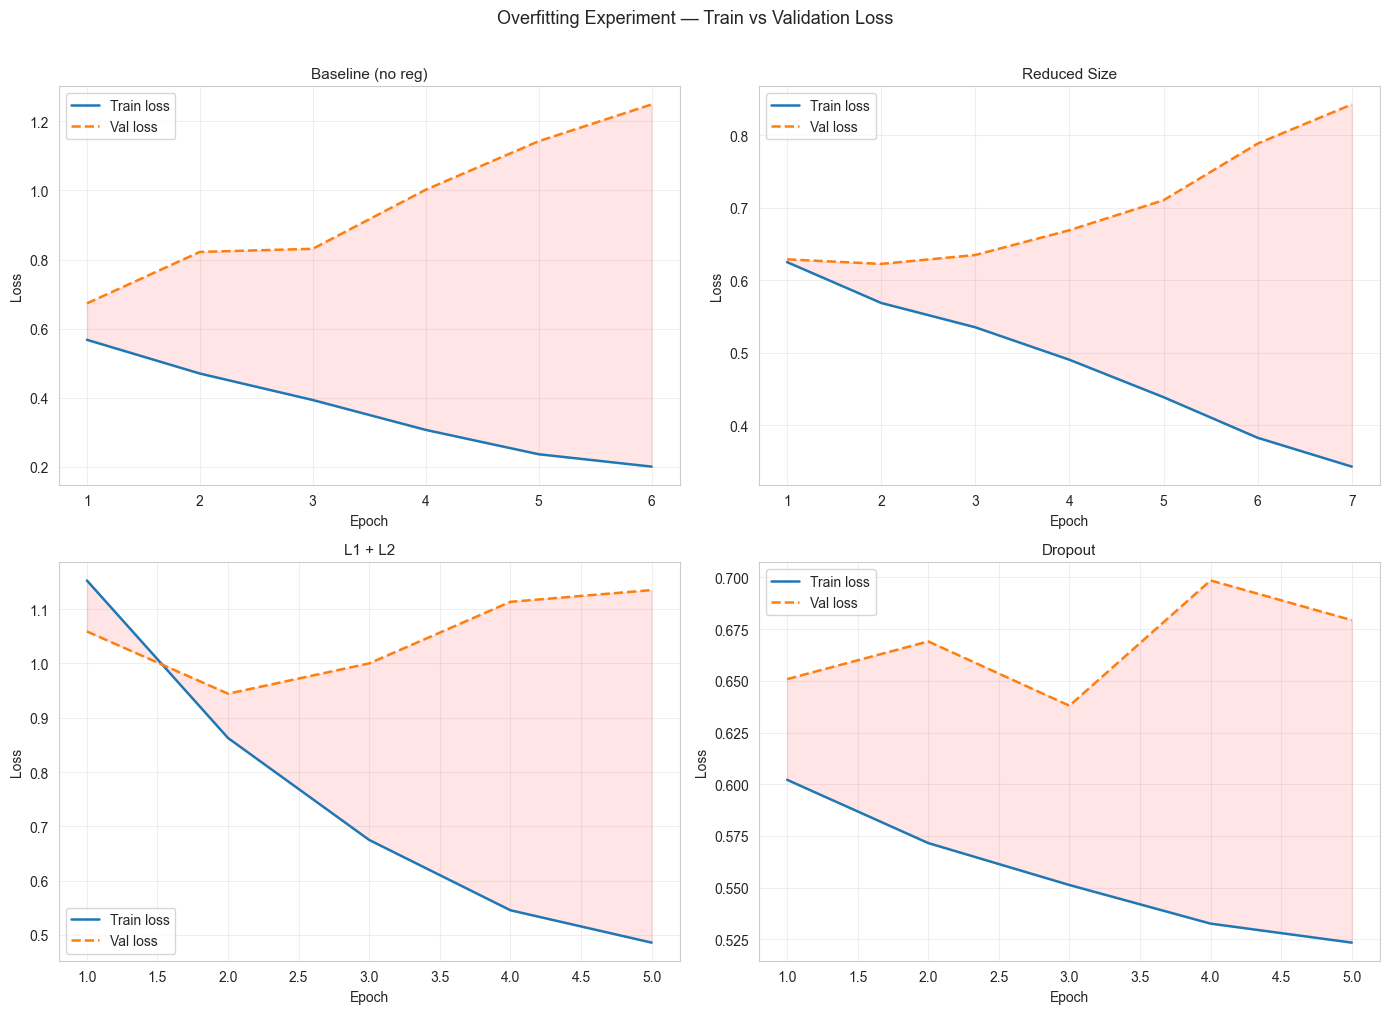

In [132]:
# ── Results table ─────────────────────────────────────────────────────────────
exp_df = pd.DataFrame(exp_results).T
print("\nOverfitting Experiment Results:")
print(exp_df.to_string(float_format='{:.3f}'.format))

# ── Plot 1: Train vs Val loss curves (overfitting diagnostic) ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, hist) in zip(axes, histories.items()):
    epochs = range(1, len(hist['loss']) + 1)
    ax.plot(epochs, hist['loss'],     label='Train loss', linewidth=1.8)
    ax.plot(epochs, hist['val_loss'], label='Val loss',   linewidth=1.8, linestyle='--')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

    # Highlight the gap between train and val (overfitting zone)
    ax.fill_between(epochs,
                    hist['loss'], hist['val_loss'],
                    alpha=0.1, color='red', label='Overfit gap')

plt.suptitle('Overfitting Experiment — Train vs Validation Loss', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


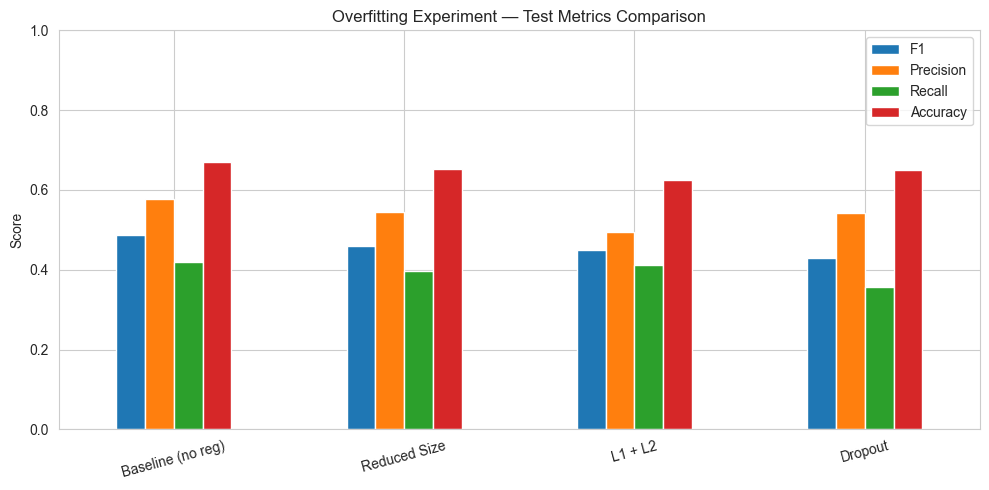

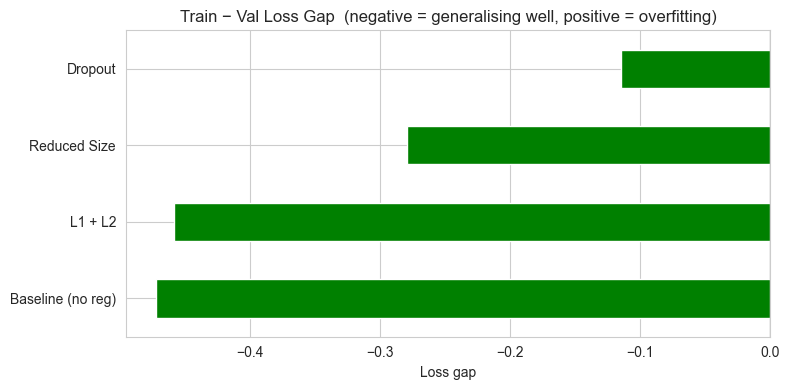

In [133]:
# ── Plot 2: F1 comparison bar chart ──────────────────────────────────────────
exp_df[['F1', 'Precision', 'Recall', 'Accuracy']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1), rot=15
)
plt.title('Overfitting Experiment — Test Metrics Comparison')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# ── Plot 3: Overfit gap bar (train loss − val loss per variant) ───────────────
gap = exp_df['Train loss'] - exp_df['Val loss']
gap.sort_values().plot(
    kind='barh', figsize=(8, 4),
    color=['green' if v <= 0 else 'tomato' for v in gap.sort_values()]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Train − Val Loss Gap  (negative = generalising well, positive = overfitting)')
plt.xlabel('Loss gap')
plt.tight_layout()
plt.show()

# Hyper-parameter Training & Selection